# Child Mortality Analysis — Cross-Sectional Regression Using World Development Indicators

**Students:** Ayoub Taychi, Hajar Lasri, Yama Saputra  
**Course:** Einführung in maschinelles Lernen  
**Task type:** Regression  
**Target variable:** Observed under-five mortality rate in 2023, U5MR 2023  
**Final design:** Cross-sectional country-level modeling dataset, one row per country

## Domain problem
Under-five mortality is a major public-health and development indicator. Countries differ substantially in child mortality, and many of these differences are associated with economic conditions, health-system capacity, demographic structure, education, food security, and infrastructure.

## Research question
**To what extent can lagged World Development Indicators predict cross-country differences in 2023 under-five mortality, and which indicators contribute most to model performance?**

## Important design choice
The panel format is used only as an intermediate structure for data auditing, exploratory analysis, and feature construction. The final machine-learning dataset is cross-sectional, with one row per country.

# Stage 1 — Problem Definition

This project predicts cross-country variation in observed U5MR 2023 using lagged World Development Indicators. The outcome is continuous, so the task is **regression**.

The project is not a 2024 forecasting exercise. U5MR 2024 is not used as a supervised target because the raw file does not provide broad observed U5MR values for 2024. A future 2024/2025 projection can be discussed only as future work.

| Item | Final design |
|---|---|
| Unit of analysis | Country |
| Final modeling dataset | One row per country |
| Target | U5MR 2023 |
| Target transformation | log(U5MR 2023) |
| Predictor level year | 2022 only |
| Trend feature | Change from 2018 to 2022 |
| Historical information | Pre-target level and recent pre-target change |
| Main task | Regression |
| Interpretation | Predictive association, not causality |

The target is observed under-five mortality in 2023. Predictor variables are constructed using only information available before 2023 to avoid temporal leakage. In the final model, feature names explicitly show their years, for example `water_access_2022` and `water_access_change_2018_2022`.

# Stage 2 — Data Collection

This stage loads the raw WDI file and checks the basic structure. No feature selection, model training, or train/test split is done here.

## 2.1 Import libraries

This cell only imports packages. Configuration, folder creation, and data loading are separated below so that the workflow can be audited step by step.

In [6]:
from pathlib import Path
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pycountry
except ImportError:
    pycountry = None

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings("ignore", category=FutureWarning)

## 2.2 Project configuration

The target remains U5MR in 2023. Predictors use explicit pre-target years, especially 2022 values and 2018-to-2022 changes.

In [7]:
RANDOM_STATE = 42
RAW_PATH = Path("WB_WDI_WIDEF (1).csv")

TARGET_YEAR = 2023
PREDICTOR_START_YEAR = 2000
PREDICTOR_LEVEL_YEAR = 2022
CHANGE_START_YEAR = 2018
CHANGE_END_YEAR = 2022

PREDICTOR_END_YEAR = TARGET_YEAR - 1
PREDICTOR_YEARS = list(range(PREDICTOR_START_YEAR, TARGET_YEAR))
CHANGE_YEARS = list(range(CHANGE_START_YEAR, CHANGE_END_YEAR + 1))
MODERN_YEARS = list(range(2000, TARGET_YEAR + 1))

MAX_INDICATOR_MISSINGNESS = 0.50
MAX_FINAL_FEATURE_MISSINGNESS = 0.50
CANDIDATE_LIMIT = 60
FINAL_INDICATOR_LIMIT = 25
FINAL_ENGINEERED_FEATURE_LIMIT = 25
REDUNDANCY_LIMIT = 0.90
ENGINEERED_REDUNDANCY_LIMIT = 0.90

assert PREDICTOR_LEVEL_YEAR < TARGET_YEAR, "Predictor year must be before target year."
assert CHANGE_END_YEAR < TARGET_YEAR, "Change window must end before target year."

print("Target year:", TARGET_YEAR)
print("Predictor level year:", PREDICTOR_LEVEL_YEAR)
print("Change feature window:", f"{CHANGE_START_YEAR} to {CHANGE_END_YEAR}")
print("Maximum original WDI indicators:", FINAL_INDICATOR_LIMIT)
print("Maximum engineered predictor columns:", FINAL_ENGINEERED_FEATURE_LIMIT)
print("Maximum missingness allowed:", MAX_INDICATOR_MISSINGNESS)

Target year: 2023
Predictor level year: 2022
Change feature window: 2018 to 2022
Maximum original WDI indicators: 25
Maximum engineered predictor columns: 25
Maximum missingness allowed: 0.5


## 2.3 Create output folders

All generated datasets, tables, plots, models, and report-ready text are saved inside one `results/` folder.

In [8]:
RESULTS_DIR = Path("results")
DATA_DIR = RESULTS_DIR / "data"
TABLE_DIR = RESULTS_DIR / "tables"
VIS_DIR = RESULTS_DIR / "visualisations"
MODEL_DIR = RESULTS_DIR / "models"
REPORT_DIR = RESULTS_DIR / "report"

for folder in [DATA_DIR, TABLE_DIR, VIS_DIR, MODEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders are ready:")
for folder in [DATA_DIR, TABLE_DIR, VIS_DIR, MODEL_DIR, REPORT_DIR]:
    print("-", folder)

Output folders are ready:
- results\data
- results\tables
- results\visualisations
- results\models
- results\report


## 2.4 Library versions

Reporting software versions improves reproducibility.

In [9]:
library_versions = pd.DataFrame({
    "library": ["Python", "pandas", "numpy", "matplotlib", "scikit-learn"],
    "version": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        plt.matplotlib.__version__,
        sklearn.__version__
    ]
})

display(library_versions)
library_versions.to_csv(TABLE_DIR / "library_versions.csv", index=False)

,library,version
0,Python,3.12.7
1,pandas,2.2.3
2,numpy,1.26.4
3,matplotlib,3.9.2
4,scikit-learn,1.5.1


## 2.5 Load the raw WDI CSV

The raw file is loaded without feature selection or cleaning. Cleaning starts in Stage 3.

In [10]:
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {RAW_PATH}. Put the raw CSV in the same folder as this notebook."
    )

raw = pd.read_csv(RAW_PATH, low_memory=False)

print("Raw dataset shape:", raw.shape)
display(raw.head(3))

Raw dataset shape: (295181, 107)


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MNE,WB_WDI_IS_RRS_TOTL_KM,_T,_T,_T,KM,...,2.490000e+02,2.490000e+02,2.490000e+02,2.500000e+02,NaN,NaN,NaN,NaN,NaN,NaN
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MMR,WB_WDI_ST_INT_XPND_CD,_T,_T,_T,USD,...,2.010000e+08,1.360000e+08,1.180000e+08,2.140000e+08,NaN,NaN,NaN,NaN,NaN,NaN
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,LUX,WB_WDI_SL_FAM_WORK_FE_ZS,F,_T,_T,PT,...,1.394918e+00,9.868241e-01,8.426004e-01,1.478158e+00,1.6546,1.686016,2.180262,1.688659,1.988782,1.98045


## 2.6 Raw structure audit

This audit documents the raw file structure before any transformation: number of rows, columns, year columns, entities, and indicators.

In [11]:
year_columns_raw = sorted(
    [c for c in raw.columns if re.fullmatch(r"\d{4}", str(c))],
    key=int
)

raw_overview = pd.DataFrame({
    "item": [
        "rows",
        "columns",
        "year columns",
        "first year",
        "last year",
        "unique entities",
        "unique indicators"
    ],
    "value": [
        raw.shape[0],
        raw.shape[1],
        len(year_columns_raw),
        min(map(int, year_columns_raw)) if year_columns_raw else np.nan,
        max(map(int, year_columns_raw)) if year_columns_raw else np.nan,
        raw["REF_AREA"].nunique() if "REF_AREA" in raw.columns else np.nan,
        raw["INDICATOR"].nunique() if "INDICATOR" in raw.columns else np.nan
    ]
})

display(raw_overview)
raw_overview.to_csv(TABLE_DIR / "raw_data_overview.csv", index=False)

,item,value
0,rows,295181
1,columns,107
2,year columns,66
3,first year,1960
4,last year,2025
5,unique entities,265
6,unique indicators,1516


## 2.7 Raw data types

The raw WDI file contains metadata columns and year columns. Year columns are converted to numeric values in Stage 3, not here, so this cell only audits the original types.

In [12]:
raw_dtype_summary = (
    raw.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="number_of_columns")
)

raw_column_audit = pd.DataFrame({
    "column": raw.columns,
    "dtype_before_cleaning": raw.dtypes.astype(str).values,
    "non_null_count": raw.notna().sum().values,
    "missing_count": raw.isna().sum().values,
    "missing_pct": raw.isna().mean().values
}).sort_values(["missing_pct", "column"], ascending=[False, True])

year_dtype_audit = raw_column_audit[raw_column_audit["column"].astype(str).isin(year_columns_raw)].copy()
metadata_dtype_audit = raw_column_audit[~raw_column_audit["column"].astype(str).isin(year_columns_raw)].copy()

print("Raw dtype summary:")
display(raw_dtype_summary)

print("Metadata column dtypes:")
display(metadata_dtype_audit)

print("Year-column dtype examples before numeric conversion:")
display(year_dtype_audit.head(10))

raw_column_audit.to_csv(TABLE_DIR / "raw_column_dtype_and_missingness_audit.csv", index=False)

Raw dtype summary:


,dtype,number_of_columns
0,float64,66
1,object,39
2,int64,2


Metadata column dtypes:


,column,dtype_before_cleaning,non_null_count,missing_count,missing_pct
2,ACTION,object,295181,0,0.0
7,AGE,object,295181,0,0.0
27,AGE_LABEL,object,295181,0,0.0
13,AGG_METHOD,object,295181,0,0.0
33,AGG_METHOD_LABEL,object,295181,0,0.0
18,COMMENT_TS,object,295181,0,0.0
10,COMP_BREAKDOWN_1,object,295181,0,0.0
30,COMP_BREAKDOWN_1_LABEL,object,295181,0,0.0
11,COMP_BREAKDOWN_2,object,295181,0,0.0
31,COMP_BREAKDOWN_2_LABEL,object,295181,0,0.0


Year-column dtype examples before numeric conversion:


,column,dtype_before_cleaning,non_null_count,missing_count,missing_pct
106,2025,float64,15857,279324,0.946280
41,1960,float64,37351,257830,0.873464
42,1961,float64,42686,252495,0.855390
43,1962,float64,43964,251217,0.851061
44,1963,float64,44898,250283,0.847897
45,1964,float64,45400,249781,0.846196
46,1965,float64,47229,247952,0.840000
47,1966,float64,47490,247691,0.839116
48,1967,float64,48130,247051,0.836948
49,1968,float64,48731,246450,0.834911


## 2.8 Raw missingness audit

This gives an initial view of missingness before country filtering and before choosing the modern 2000–2023 period.

In [13]:
year_missingness_raw = pd.DataFrame({
    "year": [int(c) for c in year_columns_raw],
    "available_values": [raw[c].notna().sum() for c in year_columns_raw],
    "missing_values": [raw[c].isna().sum() for c in year_columns_raw],
    "missing_pct": [raw[c].isna().mean() for c in year_columns_raw]
})

print("Most recent year missingness:")
display(year_missingness_raw.tail(10))

print("Columns with highest missingness:")
display(raw_column_audit.head(15))

year_missingness_raw.to_csv(TABLE_DIR / "raw_year_missingness.csv", index=False)

Most recent year missingness:


,year,available_values,missing_values,missing_pct
56,2016,229790,65391,0.221528
57,2017,227691,67490,0.228639
58,2018,226848,68333,0.231495
59,2019,223509,71672,0.242807
60,2020,220127,75054,0.254264
61,2021,214869,80312,0.272077
62,2022,200786,94395,0.319787
63,2023,181798,113383,0.384113
64,2024,124216,170965,0.579187
65,2025,15857,279324,0.946280


Columns with highest missingness:


,column,dtype_before_cleaning,non_null_count,missing_count,missing_pct
106,2025,float64,15857,279324,0.946280
41,1960,float64,37351,257830,0.873464
42,1961,float64,42686,252495,0.855390
43,1962,float64,43964,251217,0.851061
44,1963,float64,44898,250283,0.847897
45,1964,float64,45400,249781,0.846196
46,1965,float64,47229,247952,0.840000
47,1966,float64,47490,247691,0.839116
48,1967,float64,48130,247051,0.836948
49,1968,float64,48731,246450,0.834911


## 2.9 Raw duplicate audit

Duplicate checks are documented before cleaning. The country-indicator duplicate check is especially important because the final feature construction assumes one row per country-indicator pair.

In [14]:
full_duplicate_rows = int(raw.duplicated().sum())

duplicate_audit = {
    "full_duplicate_rows": full_duplicate_rows
}

if {"REF_AREA", "INDICATOR"}.issubset(raw.columns):
    duplicate_key_mask = raw.duplicated(subset=["REF_AREA", "INDICATOR"], keep=False)
    duplicate_audit["duplicate_ref_area_indicator_rows"] = int(duplicate_key_mask.sum())
    duplicate_audit["duplicate_ref_area_indicator_pairs"] = int(
        raw.loc[duplicate_key_mask, ["REF_AREA", "INDICATOR"]].drop_duplicates().shape[0]
    )

    duplicate_key_examples = (
        raw.loc[duplicate_key_mask, ["REF_AREA", "REF_AREA_LABEL", "INDICATOR", "INDICATOR_LABEL"]]
        .drop_duplicates()
        .head(20)
    )
else:
    duplicate_key_examples = pd.DataFrame()
    duplicate_audit["duplicate_ref_area_indicator_rows"] = np.nan
    duplicate_audit["duplicate_ref_area_indicator_pairs"] = np.nan

duplicate_audit_table = pd.DataFrame(
    [{"check": key, "value": value} for key, value in duplicate_audit.items()]
)

display(duplicate_audit_table)
display(duplicate_key_examples)

duplicate_audit_table.to_csv(TABLE_DIR / "raw_duplicate_audit.csv", index=False)
duplicate_key_examples.to_csv(TABLE_DIR / "raw_duplicate_key_examples.csv", index=False)

,check,value
0,full_duplicate_rows,0
1,duplicate_ref_area_indicator_rows,0
2,duplicate_ref_area_indicator_pairs,0


,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL


# Stage 3 — Data Cleaning and Preprocessing

This stage standardizes column names, detects year columns, removes non-country aggregates, identifies the U5MR target indicator, and prepares clean country-level WDI data.

Feature selection is not performed in this stage.

## 3.1 Standardize column names and numeric year values

In [15]:
wdi = raw.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country_name",
    "INDICATOR": "indicator_code",
    "INDICATOR_LABEL": "indicator_name"
}).copy()

year_columns = sorted([c for c in wdi.columns if re.fullmatch(r"\d{4}", str(c))], key=int)

for col in year_columns:
    wdi[col] = pd.to_numeric(wdi[col], errors="coerce")

print("Detected year range:", year_columns[0], "to", year_columns[-1])
print("Number of year columns:", len(year_columns))

Detected year range: 1960 to 2025
Number of year columns: 66


## 3.1.1 Verify data types after cleaning

After renaming columns, all year columns are converted to numeric values. This confirms that the ML features will be numeric and that metadata remains categorical/text.

In [16]:
post_conversion_dtype_audit = pd.DataFrame({
    "column": wdi.columns,
    "dtype_after_cleaning": wdi.dtypes.astype(str).values,
    "is_year_column": [str(col) in year_columns for col in wdi.columns],
    "non_null_count": wdi.notna().sum().values,
    "missing_count": wdi.isna().sum().values,
    "missing_pct": wdi.isna().mean().values
})

year_type_counts_after = (
    post_conversion_dtype_audit[post_conversion_dtype_audit["is_year_column"]]
    ["dtype_after_cleaning"]
    .value_counts()
    .rename_axis("dtype_after_cleaning")
    .reset_index(name="number_of_year_columns")
)

metadata_types_after = post_conversion_dtype_audit[
    ~post_conversion_dtype_audit["is_year_column"]
][["column", "dtype_after_cleaning", "missing_pct"]]

display(year_type_counts_after)
display(metadata_types_after)

post_conversion_dtype_audit.to_csv(TABLE_DIR / "post_cleaning_dtype_audit.csv", index=False)

,dtype_after_cleaning,number_of_year_columns
0,float64,66


,column,dtype_after_cleaning,missing_pct
0,STRUCTURE,object,0.0
1,STRUCTURE_ID,object,0.0
2,ACTION,object,0.0
3,FREQ,object,0.0
4,country_code,object,0.0
5,indicator_code,object,0.0
6,SEX,object,0.0
7,AGE,object,0.0
8,URBANISATION,object,0.0
9,UNIT_MEASURE,object,0.0


## 3.2 Remove regional and income-group aggregates

In [17]:
def get_iso3_country_codes():
    '''Return ISO3 country/economy codes. Kosovo (XKX) is added manually because it appears in many World Bank files.'''
    if pycountry is None:
        return None
    codes = {country.alpha_3 for country in pycountry.countries}
    codes.add("XKX")
    return codes

iso3_codes = get_iso3_country_codes()

if iso3_codes is not None:
    country_wdi = wdi[wdi["country_code"].isin(iso3_codes)].copy()
else:
    country_wdi = wdi[wdi["country_code"].astype(str).str.fullmatch(r"[A-Z]{3}", na=False)].copy()

before_duplicates = len(country_wdi)
country_wdi = country_wdi.drop_duplicates(subset=["country_code", "indicator_code"], keep="first")
removed_duplicates = before_duplicates - len(country_wdi)

print("Rows after country filter:", country_wdi.shape[0])
print("Countries/economies after country filter:", country_wdi["country_code"].nunique())
print("Indicators after country filter:", country_wdi["indicator_code"].nunique())
print("Duplicate country-indicator rows removed:", removed_duplicates)

Rows after country filter: 251650
Countries/economies after country filter: 216
Indicators after country filter: 1515
Duplicate country-indicator rows removed: 0


## 3.3 Build the indicator inventory

In [18]:
indicator_inventory = (
    country_wdi[["indicator_code", "indicator_name"]]
    .drop_duplicates()
    .sort_values("indicator_code")
    .reset_index(drop=True)
)

indicator_inventory.to_csv(TABLE_DIR / "indicator_inventory.csv", index=False)
print("Indicator inventory size:", len(indicator_inventory))
display(indicator_inventory.head(10))

Indicator inventory size: 1515


,indicator_code,indicator_name
0,WB_WDI_AG_CON_FERT_PT_ZS,Fertilizer consumption (% of fertilizer produc...
1,WB_WDI_AG_CON_FERT_ZS,Fertilizer consumption (kilograms per hectare ...
2,WB_WDI_AG_LND_AGRI_K2,Agricultural land (sq. km)
3,WB_WDI_AG_LND_AGRI_ZS,Agricultural land (% of land area)
4,WB_WDI_AG_LND_ARBL_HA,Arable land (hectares)
5,WB_WDI_AG_LND_ARBL_HA_PC,Arable land (hectares per person)
6,WB_WDI_AG_LND_ARBL_ZS,Arable land (% of land area)
7,WB_WDI_AG_LND_CREL_HA,Land under cereal production (hectares)
8,WB_WDI_AG_LND_CROP_ZS,Permanent cropland (% of land area)
9,WB_WDI_AG_LND_EL5M_RU_K2,Rural land area where elevation is below 5 met...


## 3.4 Identify the U5MR target indicator

In [19]:
u5mr_candidates = indicator_inventory[
    indicator_inventory["indicator_code"].astype(str).str.contains("SH_DYN_MORT|SH.DYN.MORT", case=False, regex=True, na=False)
    | indicator_inventory["indicator_name"].astype(str).str.contains("under-5|under five|under-five", case=False, regex=True, na=False)
].copy()

display(u5mr_candidates)

TARGET_INDICATOR_CODE = "WB_WDI_SH_DYN_MORT"

if TARGET_INDICATOR_CODE not in set(indicator_inventory["indicator_code"]):
    raise ValueError("Expected U5MR indicator WB_WDI_SH_DYN_MORT was not found. Inspect u5mr_candidates above.")

u5mr_wide = country_wdi[country_wdi["indicator_code"] == TARGET_INDICATOR_CODE].copy()
print("U5MR rows:", len(u5mr_wide))

,indicator_code,indicator_name
1003,WB_WDI_SH_DTH_MORT,Number of under-five deaths
1012,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)"
1013,WB_WDI_SH_DYN_MORT_FE,"Mortality rate, under-5, female (per 1,000 liv..."
1014,WB_WDI_SH_DYN_MORT_MA,"Mortality rate, under-5, male (per 1,000 live ..."
1047,WB_WDI_SH_MLR_NETS_ZS,Use of insecticide-treated bed nets (% of unde...


U5MR rows: 196


## 3.5 Check U5MR availability by year

In [20]:
u5mr_availability = pd.DataFrame({
    "year": [int(c) for c in year_columns],
    "available_countries": [u5mr_wide[c].notna().sum() for c in year_columns]
})

u5mr_availability.to_csv(TABLE_DIR / "u5mr_availability_by_year.csv", index=False)
display(u5mr_availability.tail(12))

,year,available_countries
54,2014,196
55,2015,196
56,2016,196
57,2017,196
58,2018,196
59,2019,196
60,2020,196
61,2021,196
62,2022,196
63,2023,196


## 3.6 Select the target year and modern working period

In [21]:
# The project configuration was defined in Stage 2.
# This cell validates that those choices are compatible with the cleaned WDI file.

if str(TARGET_YEAR) not in year_columns:
    raise ValueError(f"Target year {TARGET_YEAR} is not available as a column.")

if str(PREDICTOR_LEVEL_YEAR) not in year_columns:
    raise ValueError(f"Predictor year {PREDICTOR_LEVEL_YEAR} is not available as a column.")

if str(CHANGE_START_YEAR) not in year_columns or str(CHANGE_END_YEAR) not in year_columns:
    raise ValueError("The requested change-window years are not available as columns.")

if u5mr_wide[str(TARGET_YEAR)].notna().sum() < 100:
    raise ValueError("U5MR 2023 has too few observed values for the planned cross-sectional model.")

assert PREDICTOR_LEVEL_YEAR < TARGET_YEAR, "Predictor level year must be before the target year."
assert CHANGE_END_YEAR < TARGET_YEAR, "Change window must end before the target year."

print("Target year:", TARGET_YEAR)
print("Predictor level year:", PREDICTOR_LEVEL_YEAR)
print("Historical audit years:", PREDICTOR_YEARS[0], "to", PREDICTOR_YEARS[-1])
print("Change feature window:", CHANGE_START_YEAR, "to", CHANGE_END_YEAR)
print("U5MR countries available in target year:", u5mr_wide[str(TARGET_YEAR)].notna().sum())

Target year: 2023
Predictor level year: 2022
Historical audit years: 2000 to 2022
Change feature window: 2018 to 2022
U5MR countries available in target year: 196


## 3.7 Create the target table

In [22]:
target_df = (
    u5mr_wide[["country_code", "country_name", str(TARGET_YEAR)]]
    .rename(columns={str(TARGET_YEAR): "u5mr_2023"})
    .dropna(subset=["u5mr_2023"])
    .reset_index(drop=True)
)

target_df["log_u5mr_2023"] = np.log(target_df["u5mr_2023"])

target_df.to_csv(DATA_DIR / "target_u5mr_2023.csv", index=False)
print("Countries with observed U5MR 2023:", len(target_df))
display(target_df.head())

Countries with observed U5MR 2023: 196


,country_code,country_name,u5mr_2023,log_u5mr_2023
0,NAM,Namibia,40.7,3.706228
1,NER,Niger,114.8,4.743191
2,SSD,South Sudan,98.7,4.592085
3,MEX,Mexico,12.5,2.525729
4,MUS,Mauritius,15.2,2.721295


### Target measurement note

The target used for supervised learning is the WDI-reported value of under-five mortality in 2023. In an applied public-health setting, recent U5MR series may include statistical estimation and smoothing rather than direct annual vital-registration counts for every country. Therefore, the target is treated as the best available reported outcome for this project, while acknowledging that recent U5MR values may contain measurement uncertainty. This does not change the regression task, but it matters for cautious interpretation of model performance.

# Stage 4 — Exploratory Data Analysis

EDA examines the target distribution, availability, missingness, exploratory correlations, outliers, and a descriptive COVID-period timeline. These analyses help understand the data before final model training.

## 4.1 U5MR availability over time

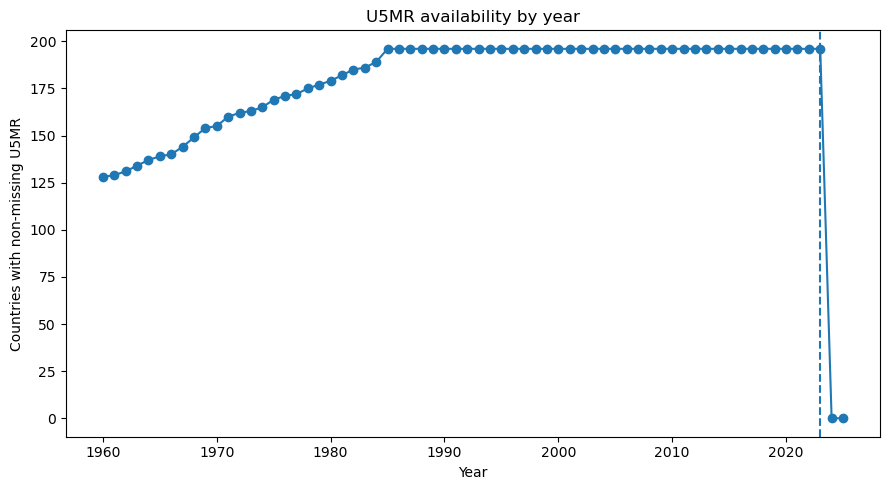

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(u5mr_availability["year"], u5mr_availability["available_countries"], marker="o")
plt.axvline(TARGET_YEAR, linestyle="--")
plt.title("U5MR availability by year")
plt.xlabel("Year")
plt.ylabel("Countries with non-missing U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_availability_by_year.png", dpi=300)
plt.show()

## 4.2 Target distribution: U5MR 2023

count    196.000000
mean      24.658673
std       24.978019
min        1.400000
25%        6.100000
50%       15.350000
75%       38.350000
max      114.800000
Name: u5mr_2023, dtype: float64

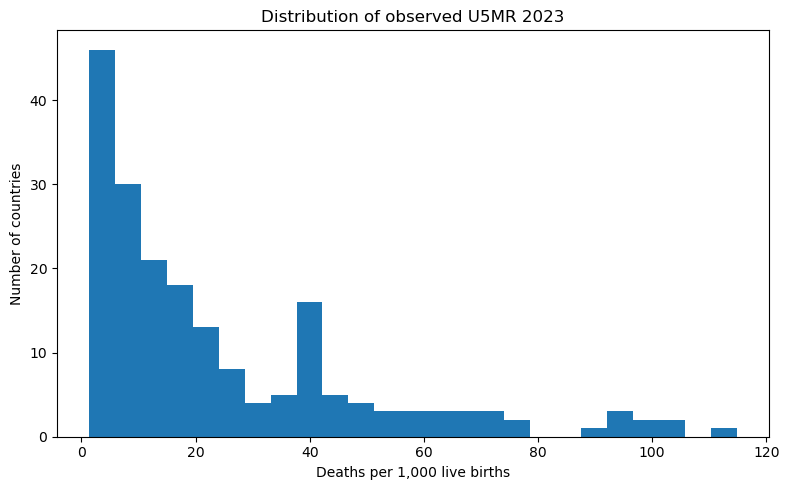

In [24]:
display(target_df["u5mr_2023"].describe())

plt.figure(figsize=(8, 5))
plt.hist(target_df["u5mr_2023"], bins=25)
plt.title("Distribution of observed U5MR 2023")
plt.xlabel("Deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.3 Log target distribution

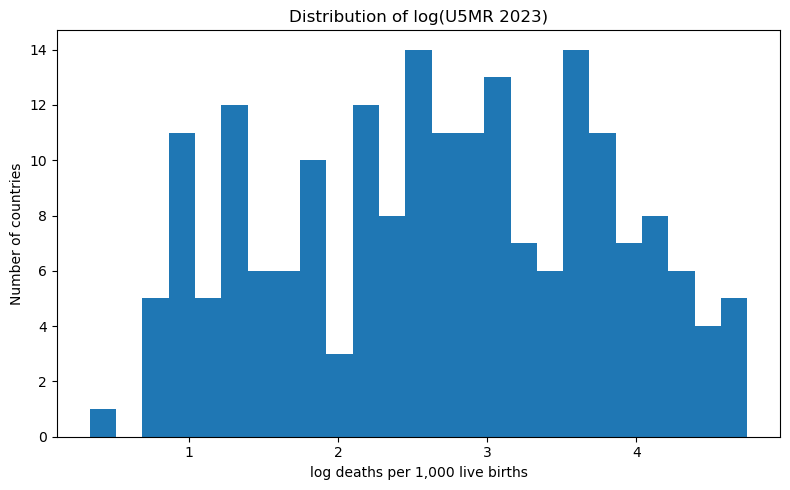

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["log_u5mr_2023"], bins=25)
plt.title("Distribution of log(U5MR 2023)")
plt.xlabel("log deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_log_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.4 Highest and lowest U5MR countries

In [26]:
print("Highest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=False).head(15))

print("Lowest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=True).head(15))

Highest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
189,NGA,Nigeria,104.9,4.653008
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
159,TCD,Chad,101.1,4.616110
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
170,SLE,Sierra Leone,94.3,4.546481
169,CAF,Central African Republic,92.2,4.523960
107,MLI,Mali,91.3,4.514151
73,BEN,Benin,77.9,4.355426


Lowest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
187,SMR,San Marino,1.4,0.336472
94,EST,Estonia,2.1,0.741937
70,SGP,Singapore,2.1,0.741937
66,SVN,Slovenia,2.2,0.788457
128,LUX,Luxembourg,2.3,0.832909
178,FIN,Finland,2.3,0.832909
109,JPN,Japan,2.4,0.875469
185,NOR,Norway,2.4,0.875469
93,BLR,Belarus,2.4,0.875469
140,SWE,Sweden,2.5,0.916291


## 4.5 Helper functions for 2022 values and 5-year changes

In [27]:
def most_recent_pre_target_values(wide_df, years, value_name="most_recent_value"):
    """Return the most recent observed value within the supplied years for each country-indicator pair.

    This helper is used mainly for EDA because it gives broad coverage.
    The final model below uses the explicit 2022 value instead of a 'most recent' feature name.
    """
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])
    most_recent_df = long_df.groupby(["country_code", "country_name", "indicator_code", "indicator_name"], as_index=False).tail(1)
    most_recent_df = most_recent_df.rename(columns={"value": value_name})
    return most_recent_df


def fixed_year_values(wide_df, year, value_name=None):
    """Return the exact value for a single year for each country-indicator pair.

    This is used for final modeling so feature names can show the year explicitly,
    for example water_access_2022.
    """
    year_col = str(year)
    if year_col not in wide_df.columns:
        raise ValueError(f"Year column {year_col} is not available.")
    if value_name is None:
        value_name = f"value_{year}"

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", year_col]].copy()
    output = output.rename(columns={year_col: value_name})
    output["source_year"] = int(year)
    output = output.dropna(subset=[value_name])
    return output


def five_year_change_values(wide_df, years):
    """Return most recent minus earliest observed value within the recent pre-target window.

    This is kept for exploratory checks. The final model uses the exact 2018-to-2022 change.
    """
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])

    first_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).first()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_start_year", "value": "change_start_value"})

    last_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).last()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_end_year", "value": "change_end_value"})

    meta = long_df[["country_code", "country_name", "indicator_code", "indicator_name"]].drop_duplicates(
        subset=["country_code", "indicator_code"]
    )

    change_df = first_df.merge(last_df, on=["country_code", "indicator_code"], how="inner")
    change_df = change_df.merge(meta, on=["country_code", "indicator_code"], how="left")
    change_df["change5y_value"] = change_df["change_end_value"] - change_df["change_start_value"]
    return change_df


def exact_change_between_years(wide_df, start_year, end_year):
    """Return exact end-year value minus exact start-year value.

    For this project, the final trend feature is value_2022 - value_2018.
    Countries missing either endpoint are treated as missing for the change feature.
    """
    start_col = str(start_year)
    end_col = str(end_year)
    for col in [start_col, end_col]:
        if col not in wide_df.columns:
            raise ValueError(f"Year column {col} is not available.")

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", start_col, end_col]].copy()
    output = output.rename(columns={
        start_col: "change_start_value",
        end_col: "change_end_value"
    })
    output["change_start_year"] = int(start_year)
    output["change_end_year"] = int(end_year)
    output[f"change_{start_year}_{end_year}"] = output["change_end_value"] - output["change_start_value"]
    output = output.dropna(subset=[f"change_{start_year}_{end_year}"])
    return output

## 4.6 Most recent pre-2023 values for EDA

In [28]:
most_recent_pre2023_eda = most_recent_pre_target_values(country_wdi, PREDICTOR_YEARS)
most_recent_pre2023_eda = most_recent_pre2023_eda[most_recent_pre2023_eda["country_code"].isin(target_df["country_code"])].copy()

print("Most recent pre-2023 country-indicator observations:", most_recent_pre2023_eda.shape)

Most recent pre-2023 country-indicator observations: (234423, 6)


## 4.7 Indicator missingness landscape

,indicator_code,indicator_name,observed_countries,median_source_year,missing_countries,missing_pct
1315,WB_WDI_SP_POP_2529_MA_5Y,"Population ages 25-29, male (% of male populat...",196,2022.0,0,0.0
1298,WB_WDI_SP_POP_0014_TO,"Population ages 0-14, total",196,2022.0,0,0.0
1257,WB_WDI_SM_POP_NETM,Net migration,196,2022.0,0,0.0
1297,WB_WDI_SP_POP_0014_MA_ZS,"Population ages 0-14, male (% of male population)",196,2022.0,0,0.0
1296,WB_WDI_SP_POP_0014_MA_IN,"Population ages 0-14, male",196,2022.0,0,0.0
1307,WB_WDI_SP_POP_1564_FE_ZS,"Population ages 15-64, female (% of female pop...",196,2022.0,0,0.0
1295,WB_WDI_SP_POP_0014_FE_ZS,"Population ages 0-14, female (% of female popu...",196,2022.0,0,0.0
1294,WB_WDI_SP_POP_0014_FE_IN,"Population ages 0-14, female",196,2022.0,0,0.0
1293,WB_WDI_SP_POP_0004_MA_5Y,"Population ages 00-04, male (% of male populat...",196,2022.0,0,0.0
1271,WB_WDI_SP_ADO_TFRT,"Adolescent fertility rate (births per 1,000 wo...",196,2022.0,0,0.0


count    1468.000000
mean        0.185262
std         0.206561
min         0.000000
25%         0.035714
50%         0.102041
75%         0.246173
max         0.994898
Name: missing_pct, dtype: float64

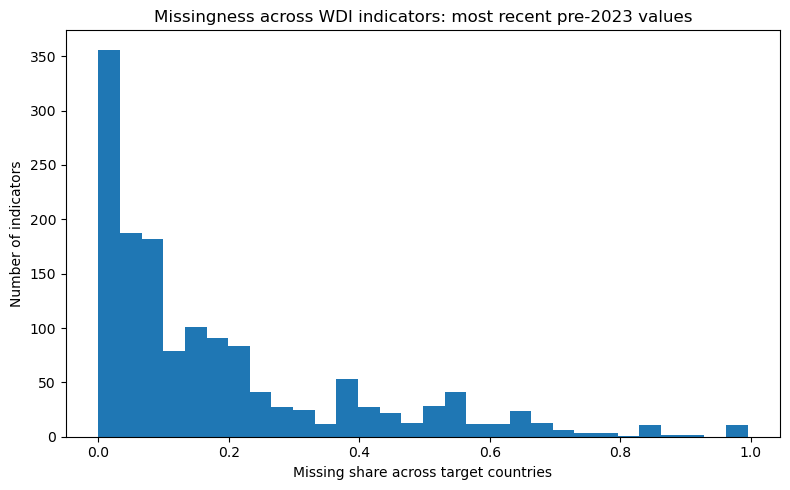

In [29]:
target_country_count = target_df["country_code"].nunique()

indicator_missingness = (
    most_recent_pre2023_eda
    .groupby(["indicator_code", "indicator_name"], as_index=False)
    .agg(
        observed_countries=("most_recent_value", "count"),
        median_source_year=("source_year", "median")
    )
)

indicator_missingness["missing_countries"] = target_country_count - indicator_missingness["observed_countries"]
indicator_missingness["missing_pct"] = indicator_missingness["missing_countries"] / target_country_count
indicator_missingness = indicator_missingness.sort_values("missing_pct")

indicator_missingness.to_csv(TABLE_DIR / "indicator_missingness_pre2023.csv", index=False)

display(indicator_missingness.head(10))

display(indicator_missingness["missing_pct"].describe())

plt.figure(figsize=(8, 5))
plt.hist(indicator_missingness["missing_pct"], bins=30)
plt.title("Missingness across WDI indicators: most recent pre-2023 values")
plt.xlabel("Missing share across target countries")
plt.ylabel("Number of indicators")
plt.tight_layout()
plt.savefig(VIS_DIR / "indicator_missingness_distribution.png", dpi=300)
plt.show()

## 4.8 Exploratory correlations with log U5MR

In [30]:
merged_for_eda_corr = most_recent_pre2023_eda.merge(
    target_df[["country_code", "log_u5mr_2023"]],
    on="country_code",
    how="inner"
)

corr_rows = []
for (code_value, name_value), group in merged_for_eda_corr.groupby(["indicator_code", "indicator_name"]):
    valid = group[["most_recent_value", "log_u5mr_2023"]].dropna()
    if len(valid) >= 50 and valid["most_recent_value"].nunique() > 1:
        corr_value = valid["most_recent_value"].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan
    corr_rows.append({
        "indicator_code": code_value,
        "indicator_name": name_value,
        "eda_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "valid_pairs": len(valid)
    })

eda_correlations = pd.DataFrame(corr_rows).merge(
    indicator_missingness[["indicator_code", "missing_pct"]],
    on="indicator_code",
    how="left"
)

eda_correlations.to_csv(TABLE_DIR / "eda_spearman_correlations_pre2023.csv", index=False)

print("Strongest negative correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr").head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

print("Strongest positive correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr", ascending=False).head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

Strongest negative correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
1281,"Life expectancy at birth, female (years)",0.000000,-0.923137,196
417,Human capital index plus (HCI+): overall score...,0.132653,-0.909149,170
406,Human capital index plus (HCI+): education pil...,0.132653,-0.905786,170
416,Human capital index plus (HCI+): overall score...,0.158163,-0.902923,165
1285,"Survival to age 65, female (% of cohort)",0.000000,-0.902693,196
1282,"Life expectancy at birth, total (years)",0.000000,-0.901748,196
1003,Lifetime risk of maternal death (1 in: rate va...,0.015306,-0.901746,193
409,Human capital index plus (HCI+): health pillar...,0.010204,-0.901562,194
1119,"Survey mean consumption or income per capita, ...",0.372449,-0.897936,123
408,Human capital index plus (HCI+): education pil...,0.107143,-0.897166,175


Strongest positive correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
965,"Mortality rate, under-5 (per 1,000 live births)",0.000000,0.995093,196
966,"Mortality rate, under-5, female (per 1,000 liv...",0.000000,0.994514,196
967,"Mortality rate, under-5, male (per 1,000 live ...",0.000000,0.994482,196
1280,"Mortality rate, infant, male (per 1,000 live b...",0.000000,0.990627,196
1279,"Mortality rate, infant (per 1,000 live births)",0.000000,0.990622,196
1278,"Mortality rate, infant, female (per 1,000 live...",0.000000,0.989790,196
971,"Mortality rate, neonatal (per 1,000 live births)",0.000000,0.983000,196
959,Probability of dying among children ages 5-9 y...,0.000000,0.947803,196
960,Probability of dying among adolescents ages 10...,0.000000,0.933682,196
1004,Lifetime risk of maternal death (%),0.015306,0.901664,193


## 4.9 U5MR outlier inspection

In [31]:
q1 = target_df["u5mr_2023"].quantile(0.25)
q3 = target_df["u5mr_2023"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = target_df[target_df["u5mr_2023"] > upper_fence].sort_values("u5mr_2023", ascending=False)

print("IQR upper fence:", round(upper_fence, 2))
print("Countries flagged as high-U5MR outliers:", len(outliers))
display(outliers)

outliers.to_csv(TABLE_DIR / "u5mr_2023_high_outliers_iqr.csv", index=False)

IQR upper fence: 86.72
Countries flagged as high-U5MR outliers: 9


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
189,NGA,Nigeria,104.9,4.653008
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
159,TCD,Chad,101.1,4.616110
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
170,SLE,Sierra Leone,94.3,4.546481
169,CAF,Central African Republic,92.2,4.523960
107,MLI,Mali,91.3,4.514151


## 4.10 Example scatter plots

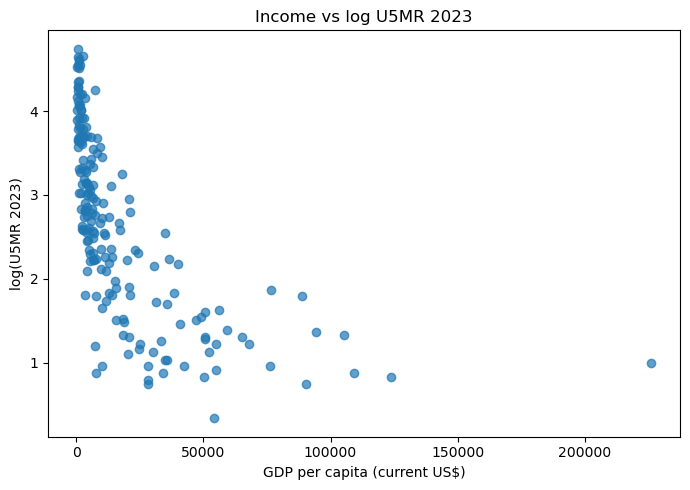

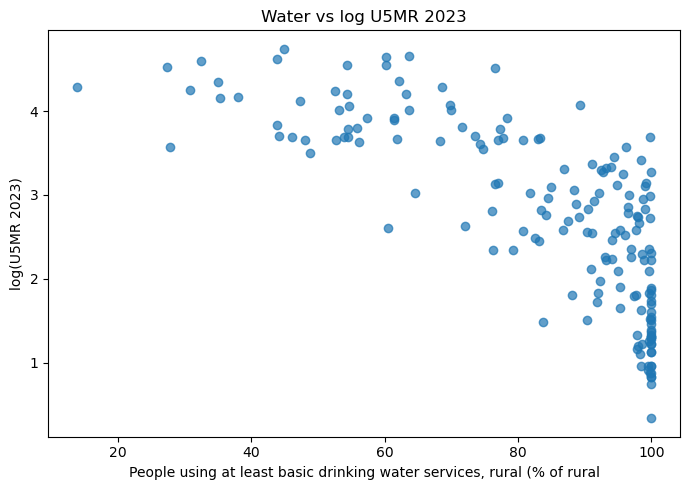

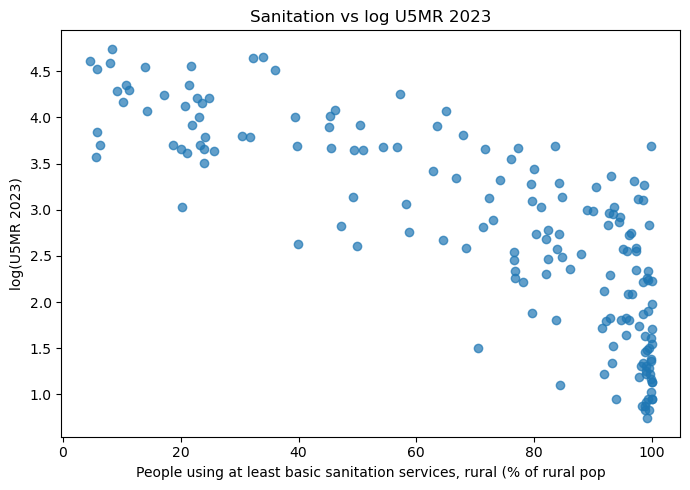

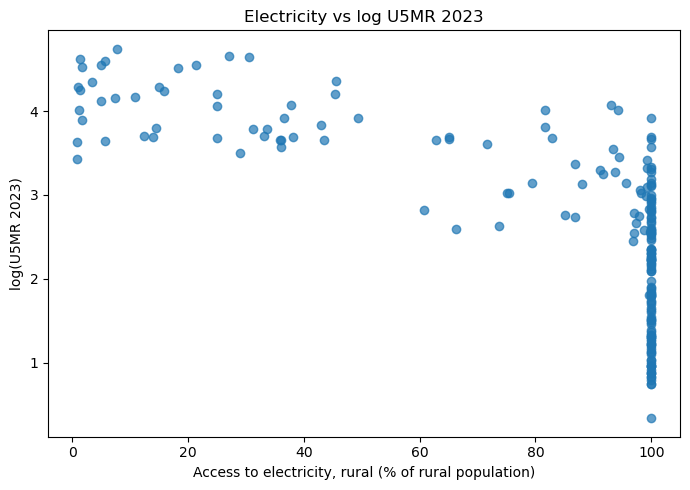

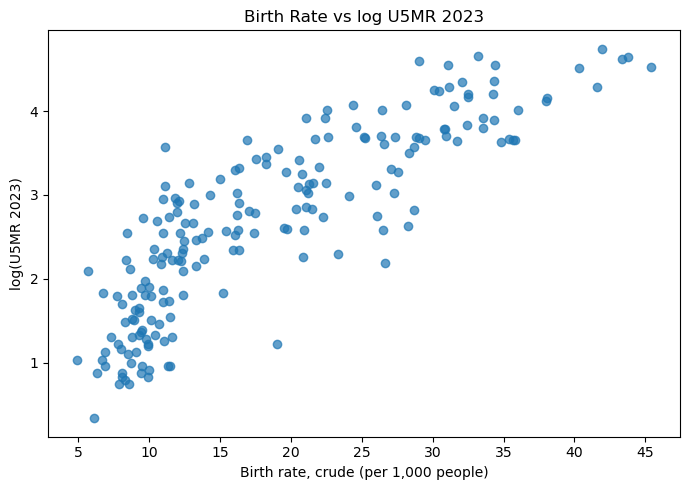

In [32]:
def find_indicator_by_keywords(indicator_table, keyword_options):
    names = indicator_table[["indicator_code", "indicator_name"]].drop_duplicates().copy()
    names["name_lower"] = names["indicator_name"].str.lower()
    for keywords in keyword_options:
        keywords = [kw.lower() for kw in keywords]
        mask = names["name_lower"].apply(lambda value: all(kw in value for kw in keywords))
        matches = names[mask]
        if len(matches) > 0:
            return matches.iloc[0]["indicator_code"], matches.iloc[0]["indicator_name"]
    return None, None

scatter_specs = {
    "income": [["gdp per capita"], ["gni per capita"], ["income per capita", "bottom 40"]],
    "water": [["basic drinking water", "population"]],
    "sanitation": [["basic sanitation", "population"]],
    "electricity": [["access to electricity"]],
    "birth_rate": [["birth rate", "crude"]]
}

for short_name, keyword_options in scatter_specs.items():
    code_value, name_value = find_indicator_by_keywords(indicator_inventory, keyword_options)
    if code_value is None:
        print(f"No matching indicator found for {short_name}.")
        continue

    plot_df = most_recent_pre2023_eda[most_recent_pre2023_eda["indicator_code"] == code_value].merge(
        target_df[["country_code", "log_u5mr_2023"]],
        on="country_code",
        how="inner"
    ).dropna(subset=["most_recent_value", "log_u5mr_2023"])

    if len(plot_df) < 30:
        continue

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df["most_recent_value"], plot_df["log_u5mr_2023"], alpha=0.7)
    plt.title(f"{short_name.replace('_', ' ').title()} vs log U5MR 2023")
    plt.xlabel(name_value[:70])
    plt.ylabel("log(U5MR 2023)")
    plt.tight_layout()
    plt.savefig(VIS_DIR / f"scatter_{short_name}_log_u5mr.png", dpi=300)
    plt.show()

## 4.11 Descriptive COVID-period U5MR timeline

This is an exploratory timeline, not a causal COVID impact analysis. U5MR values in WDI often move gradually and may be estimate-based rather than direct annual counts. Therefore, this section asks a descriptive question only:

**Was the U5MR level during the COVID period visibly higher than the surrounding pre-COVID and post-COVID periods?**

Periods used here:

- **Pre-COVID:** 2015–2019
- **COVID period:** 2020–2021
- **Post-COVID / most recent observed period:** 2022–2023

,year,median_u5mr,mean_u5mr,countries
0,2015,18.25,31.408673,196
1,2016,17.70,30.673980,196
2,2017,17.10,30.211735,196
3,2018,16.45,28.440816,196
4,2019,16.20,28.167857,196
5,2020,15.65,26.718878,196
6,2021,15.15,26.241837,196
7,2022,14.70,26.838776,196
8,2023,15.35,24.658673,196


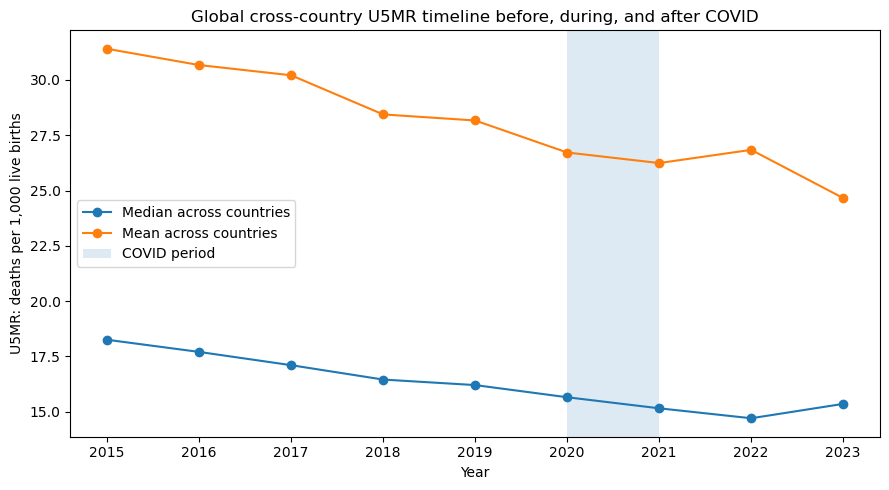

In [33]:
covid_years = list(range(2015, TARGET_YEAR + 1))
u5mr_timeline = u5mr_wide[["country_code", "country_name"] + [str(y) for y in covid_years]].melt(
    id_vars=["country_code", "country_name"],
    var_name="year",
    value_name="u5mr"
)
u5mr_timeline["year"] = u5mr_timeline["year"].astype(int)
u5mr_timeline = u5mr_timeline.dropna(subset=["u5mr"])

global_timeline = (
    u5mr_timeline
    .groupby("year", as_index=False)
    .agg(
        median_u5mr=("u5mr", "median"),
        mean_u5mr=("u5mr", "mean"),
        countries=("country_code", "nunique")
    )
)

global_timeline.to_csv(TABLE_DIR / "u5mr_covid_timeline_global.csv", index=False)
display(global_timeline)

plt.figure(figsize=(9, 5))
plt.plot(global_timeline["year"], global_timeline["median_u5mr"], marker="o", label="Median across countries")
plt.plot(global_timeline["year"], global_timeline["mean_u5mr"], marker="o", label="Mean across countries")
plt.axvspan(2020, 2021, alpha=0.15, label="COVID period")
plt.title("Global cross-country U5MR timeline before, during, and after COVID")
plt.xlabel("Year")
plt.ylabel("U5MR: deaths per 1,000 live births")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_timeline_before_during_after_covid.png", dpi=300)
plt.show()

## 4.12 Compare pre-COVID, COVID, and post-COVID country averages

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
pre_covid_2015_2019,196.0,29.780612,32.591280,1.82,7.3450,17.130,45.5350,201.96
covid_2020_2021,196.0,26.480357,27.802460,1.55,6.5000,15.575,42.0750,146.95
post_covid_2022_2023,196.0,25.748724,29.520891,1.45,6.1375,15.500,39.1625,239.80
covid_minus_pre,196.0,-3.300255,7.988572,-103.26,-4.1850,-1.535,-0.3450,4.75
post_minus_covid,196.0,-0.731633,7.043025,-7.25,-2.0625,-0.650,-0.1500,92.85


C:\Users\ayoub\AppData\Local\Temp\ipykernel_3476\1975163887.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])


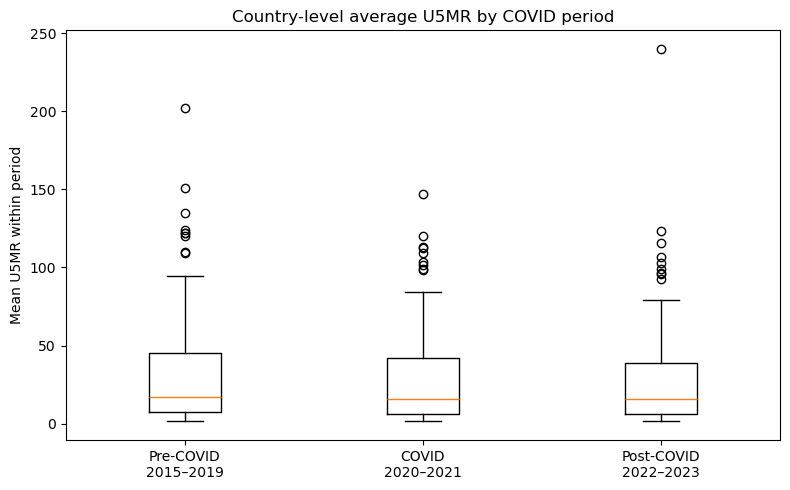

In [34]:
def assign_covid_period(year):
    if 2015 <= year <= 2019:
        return "pre_covid_2015_2019"
    if 2020 <= year <= 2021:
        return "covid_2020_2021"
    if 2022 <= year <= 2023:
        return "post_covid_2022_2023"
    return np.nan

period_df = u5mr_timeline.copy()
period_df["period"] = period_df["year"].apply(assign_covid_period)
period_df = period_df.dropna(subset=["period"])

country_period = (
    period_df
    .groupby(["country_code", "country_name", "period"], as_index=False)
    .agg(mean_u5mr=("u5mr", "mean"))
)

period_wide = country_period.pivot_table(
    index=["country_code", "country_name"],
    columns="period",
    values="mean_u5mr"
).reset_index()

period_columns = ["pre_covid_2015_2019", "covid_2020_2021", "post_covid_2022_2023"]
period_wide = period_wide.dropna(subset=period_columns)
period_wide["covid_minus_pre"] = period_wide["covid_2020_2021"] - period_wide["pre_covid_2015_2019"]
period_wide["post_minus_covid"] = period_wide["post_covid_2022_2023"] - period_wide["covid_2020_2021"]

period_summary = period_wide[period_columns + ["covid_minus_pre", "post_minus_covid"]].describe().T
period_summary.to_csv(TABLE_DIR / "u5mr_covid_period_comparison_summary.csv")
period_wide.to_csv(TABLE_DIR / "u5mr_covid_period_country_comparison.csv", index=False)

display(period_summary)

plot_period_long = period_wide.melt(
    id_vars=["country_code", "country_name"],
    value_vars=period_columns,
    var_name="period",
    value_name="mean_u5mr"
)

plt.figure(figsize=(8, 5))
plot_data = [plot_period_long.loc[plot_period_long["period"] == p, "mean_u5mr"] for p in period_columns]
plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])
plt.title("Country-level average U5MR by COVID period")
plt.ylabel("Mean U5MR within period")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_boxplot_covid_periods.png", dpi=300)
plt.show()

### COVID-period interpretation note

The COVID-period comparison is useful context for the project, but it should remain in EDA. It should not replace the main research question, which is cross-sectional prediction of U5MR 2023 from lagged WDI indicators.

The timeline should also be interpreted cautiously because WDI U5MR values are annual country-level estimates and may be smoothed over time. A gradual trend during 2020–2023 therefore does not prove that the pandemic had no effect on child mortality. The analysis is descriptive, not causal.

# Stage 5 — Leakage-Safe Feature Pool Construction

This stage constructs a large cross-sectional pool of lagged predictor values. It does **not** use the test-set target to choose predictors.

Key choices:

- Use exact predictor levels from **2022** only.
- Use exact recent changes from **2018 to 2022** only.
- Remove indicators with more than **50% missingness** in the 2022 predictor value.
- Remove engineered predictor columns with more than **50% missingness** in the training data.
- Remove target-like indicators such as mortality, death, survival, life expectancy, probability of dying, and close child mortality outcomes.

The supervised step that ranks indicators by correlation with the target is delayed until after the train/test split, and it is performed on training countries only.

## 5.1 Configuration for feature construction and selection

In [35]:
MAX_INDICATOR_MISSINGNESS = 0.50
MAX_FINAL_FEATURE_MISSINGNESS = 0.50
CANDIDATE_LIMIT = 60
FINAL_INDICATOR_LIMIT = 25
FINAL_ENGINEERED_FEATURE_LIMIT = 25
REDUNDANCY_LIMIT = 0.90
ENGINEERED_REDUNDANCY_LIMIT = 0.90

LEVEL_VALUE_COLUMN = f"value_{PREDICTOR_LEVEL_YEAR}"
CHANGE_VALUE_COLUMN = f"change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

print("Target year:", TARGET_YEAR)
print("Predictor level year:", PREDICTOR_LEVEL_YEAR)
print("Change feature:", CHANGE_START_YEAR, "to", CHANGE_END_YEAR)
print("Maximum allowed indicator missingness:", MAX_INDICATOR_MISSINGNESS)
print("Maximum allowed final engineered-feature missingness:", MAX_FINAL_FEATURE_MISSINGNESS)
print("Candidate indicator shortlist size:", CANDIDATE_LIMIT)
print("Maximum final original WDI indicators:", FINAL_INDICATOR_LIMIT)
print("Maximum final engineered predictor columns:", FINAL_ENGINEERED_FEATURE_LIMIT)
print("Maximum allowed redundancy among engineered predictors:", ENGINEERED_REDUNDANCY_LIMIT)

# Exact 2022 values are used for final feature screening and modeling.
all_2022_values = fixed_year_values(country_wdi, PREDICTOR_LEVEL_YEAR, value_name=LEVEL_VALUE_COLUMN)
all_2022_values = all_2022_values[all_2022_values["country_code"].isin(target_df["country_code"])].copy()

target_country_count = target_df["country_code"].nunique()
indicator_missingness_2022 = (
    all_2022_values
    .groupby(["indicator_code", "indicator_name"], as_index=False)
    .agg(observed_countries=(LEVEL_VALUE_COLUMN, "count"))
)
indicator_missingness_2022["missing_countries"] = target_country_count - indicator_missingness_2022["observed_countries"]
indicator_missingness_2022["missing_pct"] = indicator_missingness_2022["missing_countries"] / target_country_count
indicator_missingness_2022["source_year"] = PREDICTOR_LEVEL_YEAR
indicator_missingness_2022 = indicator_missingness_2022.sort_values("missing_pct")

indicator_missingness_2022.to_csv(TABLE_DIR / "indicator_missingness_2022.csv", index=False)
display(indicator_missingness_2022.head(10))

Target year: 2023
Predictor level year: 2022
Change feature: 2018 to 2022
Maximum allowed indicator missingness: 0.5
Maximum allowed final engineered-feature missingness: 0.5
Candidate indicator shortlist size: 60
Maximum final original WDI indicators: 25
Maximum final engineered predictor columns: 25
Maximum allowed redundancy among engineered predictors: 0.9


,indicator_code,indicator_name,observed_countries,missing_countries,missing_pct,source_year
1142,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...",196,0,0.0,2022
1095,WB_WDI_SP_POP_0014_MA_IN,"Population ages 0-14, male",196,0,0.0,2022
1096,WB_WDI_SP_POP_0014_MA_ZS,"Population ages 0-14, male (% of male population)",196,0,0.0,2022
1097,WB_WDI_SP_POP_0014_TO,"Population ages 0-14, total",196,0,0.0,2022
1098,WB_WDI_SP_POP_0014_TO_ZS,Population ages 0-14 (% of total population),196,0,0.0,2022
1099,WB_WDI_SP_POP_0509_FE_5Y,"Population ages 05-09, female (% of female pop...",196,0,0.0,2022
1100,WB_WDI_SP_POP_0509_MA_5Y,"Population ages 05-09, male (% of male populat...",196,0,0.0,2022
1101,WB_WDI_SP_POP_1014_FE_5Y,"Population ages 10-14, female (% of female pop...",196,0,0.0,2022
1102,WB_WDI_SP_POP_1014_MA_5Y,"Population ages 10-14, male (% of male populat...",196,0,0.0,2022
1103,WB_WDI_SP_POP_1519_FE_5Y,"Population ages 15-19, female (% of female pop...",196,0,0.0,2022


## 5.2 Remove target-like and leakage-risk indicators

In [36]:
def is_target_like_indicator(indicator_name, indicator_code):
    """Flag indicators that are too close to the U5MR target or child-mortality outcomes."""
    text = f"{indicator_name} {indicator_code}".lower()
    leakage_terms = [
        "mortality", "death", "deaths", "dying", "survival", "life expectancy", "lifespan",
        "infant mortality", "neonatal", "under-5", "under five", "under-five",
        "stillbirth", "hci", "human capital index"
    ]
    return any(term in text for term in leakage_terms)

eligible_indicator_base = indicator_missingness_2022.copy()
eligible_indicator_base["target_like"] = eligible_indicator_base.apply(
    lambda row: is_target_like_indicator(row["indicator_name"], row["indicator_code"]),
    axis=1
)

eligible_indicator_base["passes_missingness"] = eligible_indicator_base["missing_pct"] <= MAX_INDICATOR_MISSINGNESS

eligible_indicators = eligible_indicator_base[
    eligible_indicator_base["passes_missingness"] & (~eligible_indicator_base["target_like"])
].copy()

excluded_target_like = eligible_indicator_base[eligible_indicator_base["target_like"]].copy()
excluded_high_missing = eligible_indicator_base[~eligible_indicator_base["passes_missingness"]].copy()

eligible_indicators.to_csv(TABLE_DIR / "eligible_indicators_after_2022_missingness_and_leakage_filters.csv", index=False)
excluded_target_like.to_csv(TABLE_DIR / "excluded_target_like_indicators.csv", index=False)
excluded_high_missing.to_csv(TABLE_DIR / "excluded_high_2022_missingness_indicators.csv", index=False)

print("Indicators with 2022 observations before filters:", len(indicator_missingness_2022))
print("Indicators after <=50% 2022 missingness and leakage filters:", len(eligible_indicators))
print("Target-like indicators excluded:", len(excluded_target_like))
print("High-2022-missingness indicators excluded:", len(excluded_high_missing))

Indicators with 2022 observations before filters: 1251
Indicators after <=50% 2022 missingness and leakage filters: 874
Target-like indicators excluded: 32
High-2022-missingness indicators excluded: 347


## 5.3 Build 2022-level and 2018-to-2022-change feature pools

In [37]:
eligible_codes = set(eligible_indicators["indicator_code"])

level_2022_pool = all_2022_values[all_2022_values["indicator_code"].isin(eligible_codes)].copy()

change_2018_2022_pool = exact_change_between_years(country_wdi, CHANGE_START_YEAR, CHANGE_END_YEAR)
change_2018_2022_pool = change_2018_2022_pool[
    change_2018_2022_pool["country_code"].isin(target_df["country_code"])
    & change_2018_2022_pool["indicator_code"].isin(eligible_codes)
].copy()

level_2022_pool.to_csv(DATA_DIR / "feature_pool_2022_level_long.csv", index=False)
change_2018_2022_pool.to_csv(DATA_DIR / "feature_pool_change_2018_2022_long.csv", index=False)

print("2022-level feature pool:", level_2022_pool.shape)
print("2018-to-2022 change feature pool:", change_2018_2022_pool.shape)

2022-level feature pool: (140971, 6)
2018-to-2022 change feature pool: (136515, 9)


# Stage 6 — Data Splitting

The split is done at the country level. Stratification uses quartiles of log U5MR so that low- and high-mortality countries are represented in both sets.

From this point onward, all supervised feature selection is performed using the training countries only.

## 6.1 Country-level train/test split

In [38]:
stratify_bins = pd.qcut(
    target_df["log_u5mr_2023"],
    q=4,
    labels=False,
    duplicates="drop"
)

train_country_df, test_country_df = train_test_split(
    target_df[["country_code", "country_name", "u5mr_2023", "log_u5mr_2023"]],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify_bins
)

train_codes = set(train_country_df["country_code"])
test_codes = set(test_country_df["country_code"])

print("Train countries:", len(train_country_df))
print("Test countries:", len(test_country_df))

train_country_df.to_csv(DATA_DIR / "train_countries.csv", index=False)
test_country_df.to_csv(DATA_DIR / "test_countries.csv", index=False)

Train countries: 147
Test countries: 49


## 6.2 Check train/test balance

In [39]:
split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "countries": [len(train_country_df), len(test_country_df)],
    "mean_u5mr": [train_country_df["u5mr_2023"].mean(), test_country_df["u5mr_2023"].mean()],
    "median_u5mr": [train_country_df["u5mr_2023"].median(), test_country_df["u5mr_2023"].median()],
    "min_u5mr": [train_country_df["u5mr_2023"].min(), test_country_df["u5mr_2023"].min()],
    "max_u5mr": [train_country_df["u5mr_2023"].max(), test_country_df["u5mr_2023"].max()]
})

display(split_summary)
split_summary.to_csv(TABLE_DIR / "train_test_split_summary.csv", index=False)

,split,countries,mean_u5mr,median_u5mr,min_u5mr,max_u5mr
0,train,147,24.171429,15.7,1.4,114.8
1,test,49,26.120408,15.2,2.2,104.0


# Stage 7 — Train-Only Feature Selection and Final Dataset Construction

## 7.1 Training-only Spearman screening

In [40]:
train_level_for_selection = level_2022_pool[level_2022_pool["country_code"].isin(train_codes)].merge(
    train_country_df[["country_code", "log_u5mr_2023"]],
    on="country_code",
    how="inner"
)

selection_rows = []
for (code_value, name_value), group in train_level_for_selection.groupby(["indicator_code", "indicator_name"]):
    valid = group[[LEVEL_VALUE_COLUMN, "log_u5mr_2023"]].dropna()
    if len(valid) >= 40 and valid[LEVEL_VALUE_COLUMN].nunique() > 1:
        corr_value = valid[LEVEL_VALUE_COLUMN].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan
    selection_rows.append({
        "indicator_code": code_value,
        "indicator_name": name_value,
        "train_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "train_valid_pairs": len(valid)
    })

train_correlations = pd.DataFrame(selection_rows).merge(
    eligible_indicators[["indicator_code", "missing_pct", "source_year"]],
    on="indicator_code",
    how="left"
)

candidate_60 = (
    train_correlations
    .dropna(subset=["abs_corr"])
    .sort_values("abs_corr", ascending=False)
    .head(CANDIDATE_LIMIT)
    .copy()
)
candidate_60["candidate_rank"] = range(1, len(candidate_60) + 1)

candidate_60.to_csv(TABLE_DIR / "candidate_60_indicators_train_only_2022.csv", index=False)

display(candidate_60[["candidate_rank", "indicator_name", "missing_pct", "train_spearman_corr", "abs_corr", "train_valid_pairs"]].head(20))

,candidate_rank,indicator_name,missing_pct,train_spearman_corr,abs_corr,train_valid_pairs
603,1,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140,142
611,2,Domestic general government health expenditure...,0.030612,-0.888415,0.888415,142
723,3,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283,147
300,4,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805,143
573,5,Risk of impoverishing expenditure for surgical...,0.423469,0.878992,0.878992,82
732,6,Population ages 0-14 (% of total population),0.000000,0.877666,0.877666,147
728,7,"Population ages 0-14, female (% of female popu...",0.000000,0.872016,0.872016,147
610,8,Domestic general government health expenditure...,0.030612,-0.871714,0.871714,143
449,9,"GNI per capita, PPP (constant 2021 internation...",0.219388,-0.870400,0.870400,115
602,10,Current health expenditure per capita (current...,0.030612,-0.869727,0.869727,143


## 7.2 Remove redundant indicators using training data only

In [41]:
candidate_codes = candidate_60["indicator_code"].tolist()

candidate_train_matrix = (
    level_2022_pool[
        level_2022_pool["country_code"].isin(train_codes)
        & level_2022_pool["indicator_code"].isin(candidate_codes)
    ]
    .pivot(index="country_code", columns="indicator_code", values=LEVEL_VALUE_COLUMN)
    .reindex(columns=candidate_codes)
)

candidate_redundancy_corr = candidate_train_matrix.corr(method="spearman").abs()

selected_codes = []
redundancy_rows = []

for _, row in candidate_60.iterrows():
    code_value = row["indicator_code"]
    name_value = row["indicator_name"]

    if len(selected_codes) == 0:
        selected_codes.append(code_value)
        redundancy_rows.append({
            "indicator_code": code_value,
            "indicator_name": name_value,
            "decision": "selected",
            "max_abs_corr_with_selected": np.nan
        })
    else:
        max_corr = candidate_redundancy_corr.loc[code_value, selected_codes].max(skipna=True)
        if pd.isna(max_corr) or max_corr < REDUNDANCY_LIMIT:
            selected_codes.append(code_value)
            decision = "selected"
        else:
            decision = "excluded_redundant"

        redundancy_rows.append({
            "indicator_code": code_value,
            "indicator_name": name_value,
            "decision": decision,
            "max_abs_corr_with_selected": max_corr
        })

    if len(selected_codes) >= FINAL_INDICATOR_LIMIT:
        break

redundancy_audit = pd.DataFrame(redundancy_rows)
final_indicators = candidate_60[candidate_60["indicator_code"].isin(selected_codes)].copy()
final_indicators["final_rank"] = range(1, len(final_indicators) + 1)

print("Selected original WDI indicators:", len(final_indicators))
print("Maximum allowed original WDI indicators:", FINAL_INDICATOR_LIMIT)

display(final_indicators[["final_rank", "indicator_name", "missing_pct", "train_spearman_corr", "abs_corr"]])

Selected original WDI indicators: 18
Maximum allowed original WDI indicators: 25


,final_rank,indicator_name,missing_pct,train_spearman_corr,abs_corr
603,1,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140
723,2,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283
300,3,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805
302,4,Secure Internet servers (per 1 million people),0.005102,-0.852474,0.852474
776,5,"Population ages 80 and above, male (% of male ...",0.000000,-0.844607,0.844607
720,6,Prevalence of moderate or severe food insecuri...,0.260204,0.841557,0.841557
738,7,"Population ages 15-19, male (% of male populat...",0.000000,0.838677,0.838677
549,8,People using at least basic drinking water ser...,0.056122,-0.836031,0.836031
566,9,"Physicians (per 1,000 people)",0.362245,-0.835177,0.835177
575,10,People using at least basic sanitation service...,0.132653,-0.832553,0.832553


## 7.3 Predictor names and domains

### 7.3.1 Group indicators by domain

In [42]:
def classify_indicator_domain(indicator_name):
    """Assign each WDI indicator to a broad interpretable domain."""
    name = str(indicator_name).lower()

    if any(term in name for term in [
        "health expenditure", "physician", "nurse", "midwife", "hospital",
        "immunization", "vaccine", "anemia", "uhc", "service coverage",
        "medical", "surgical"
    ]):
        return "health system"

    if any(term in name for term in [
        "water", "sanitation", "electric", "internet", "broadband", "server"
    ]):
        return "infrastructure"

    if any(term in name for term in [
        "gdp", "gni", "income", "poverty", "employment", "wage",
        "consumption", "prosperity"
    ]):
        return "economic"

    if any(term in name for term in [
        "population", "birth rate", "fertility", "age", "urban",
        "rural", "adolescent"
    ]):
        return "demographic"

    if any(term in name for term in [
        "school", "education", "literacy", "reading", "learning",
        "pupil", "food", "undernourishment", "nutrition"
    ]):
        return "education/social"

    return "other"


### 7.3.2 Create concise predictor names

In [43]:
def make_simple_indicator_name(indicator_name, indicator_code, used_names):
    """Create short, clear predictor names for modeling outputs and plots."""
    name = str(indicator_name).lower()

    if "anemia" in name and "children" in name:
        base = "child_anemia"
    elif "birth rate" in name:
        base = "birth_rate"
    elif "adolescent fertility" in name:
        base = "adolescent_fertility"
    elif "fertility" in name:
        base = "fertility"
    elif "at least basic drinking water" in name or "drinking water" in name:
        base = "water_access"
    elif "at least basic sanitation" in name or "sanitation" in name:
        base = "sanitation_access"
    elif "access to electricity" in name or "electric" in name:
        base = "electricity_access"
    elif "school enrollment" in name and "secondary" in name:
        base = "secondary_school"
    elif "school enrollment" in name and "primary" in name:
        base = "primary_school"
    elif "reading proficiency" in name or "learning poverty" in name:
        base = "reading_proficiency"
    elif "literacy" in name:
        base = "literacy"
    elif "bottom 40" in name and "income" in name:
        base = "income_bottom40"
    elif "income per capita" in name:
        base = "income_pc"
    elif "gdp per capita" in name:
        base = "gdp_pc"
    elif "gni per capita" in name:
        base = "gni_pc"
    elif "poverty" in name:
        base = "poverty"
    elif "food insecurity" in name:
        base = "food_insecurity"
    elif "undernourishment" in name:
        base = "undernourishment"
    elif "physicians" in name:
        base = "physicians"
    elif "nurses" in name or "midwives" in name:
        base = "nurses_midwives"
    elif "health expenditure" in name:
        base = "health_exp"
    elif "population ages 80 and above" in name:
        base = "elderly_share"
    elif "population ages 15-19" in name:
        base = "youth_15_19_share"
    elif "population ages 0-14" in name:
        base = "children_share"
    elif "secure internet servers" in name:
        base = "secure_servers"
    elif "individuals using the internet" in name:
        base = "internet_use"
    elif "wage and salaried workers" in name:
        base = "wage_salaried_workers"
    elif "researchers in r&d" in name or "researchers" in name:
        base = "researchers_rd"
    else:
        words = re.findall(r"[a-z]+", name)
        stop_words = {
            "the", "and", "for", "with", "from", "into", "per", "of", "in",
            "to", "by", "at", "as", "total", "current", "constant",
            "annual", "percentage", "percent", "people", "population",
            "female", "male", "modeled", "estimate", "international",
            "dollars", "2017", "ppp"
        }
        important_words = [
            word for word in words
            if word not in stop_words and len(word) > 2
        ][:3]
        base = "_".join(important_words) if important_words else str(indicator_code).lower()

    base = re.sub(r"[^a-z0-9]+", "_", base).strip("_")[:30]

    candidate = base
    counter = 2
    while candidate in used_names:
        candidate = f"{base}_{counter}"
        counter += 1

    used_names.add(candidate)
    return candidate


### 7.3.3 Apply names and save the indicator dictionary

In [44]:
used_simple_names = set()

final_indicators["domain"] = final_indicators["indicator_name"].apply(classify_indicator_domain)

final_indicators["simple_name"] = [
    make_simple_indicator_name(name, code, used_simple_names)
    for name, code in zip(final_indicators["indicator_name"], final_indicators["indicator_code"])
]

final_indicator_dictionary = final_indicators[[
    "final_rank",
    "simple_name",
    "domain",
    "indicator_code",
    "indicator_name",
    "missing_pct",
    "train_spearman_corr",
    "abs_corr",
    "train_valid_pairs"
]].copy()

final_indicator_dictionary.to_csv(
    TABLE_DIR / "final_indicator_dictionary_clear_train_only.csv",
    index=False
)
redundancy_audit.to_csv(TABLE_DIR / "redundancy_audit_train_only.csv", index=False)

print("Selected original WDI indicators:", len(final_indicator_dictionary))
display(final_indicator_dictionary)


Selected original WDI indicators: 18


,final_rank,simple_name,domain,indicator_code,indicator_name,missing_pct,train_spearman_corr,abs_corr,train_valid_pairs
603,1,health_exp,health system,WB_WDI_SH_XPD_CHEX_PP_CD,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140,142
723,2,birth_rate,demographic,WB_WDI_SP_DYN_CBRT_IN,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283,147
300,3,fixed_broadband_subscriptions,infrastructure,WB_WDI_IT_NET_BBND_P2,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805,143
302,4,secure_servers,infrastructure,WB_WDI_IT_NET_SECR_P6,Secure Internet servers (per 1 million people),0.005102,-0.852474,0.852474,146
776,5,elderly_share,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...",0.000000,-0.844607,0.844607,147
720,6,food_insecurity,demographic,WB_WDI_SN_ITK_MSFI_ZS,Prevalence of moderate or severe food insecuri...,0.260204,0.841557,0.841557,109
738,7,youth_15_19_share,demographic,WB_WDI_SP_POP_1519_MA_5Y,"Population ages 15-19, male (% of male populat...",0.000000,0.838677,0.838677,147
549,8,water_access,infrastructure,WB_WDI_SH_H2O_BASW_ZS,People using at least basic drinking water ser...,0.056122,-0.836031,0.836031,140
566,9,physicians,health system,WB_WDI_SH_MED_PHYS_ZS,"Physicians (per 1,000 people)",0.362245,-0.835177,0.835177,93
575,10,sanitation_access,infrastructure,WB_WDI_SH_STA_BASS_UR_ZS,People using at least basic sanitation service...,0.132653,-0.832553,0.832553,129


## 7.4 Create final 2022-level and 2018-to-2022-change features

In [45]:
final_code_to_name = dict(zip(final_indicators["indicator_code"], final_indicators["simple_name"]))
final_codes = list(final_code_to_name.keys())

level_final_long = level_2022_pool[level_2022_pool["indicator_code"].isin(final_codes)].copy()
level_final_long["feature"] = level_final_long["indicator_code"].map(final_code_to_name) + f"_{PREDICTOR_LEVEL_YEAR}"

change_final_long = change_2018_2022_pool[change_2018_2022_pool["indicator_code"].isin(final_codes)].copy()
change_final_long["feature"] = (
    change_final_long["indicator_code"].map(final_code_to_name)
    + f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"
)

level_wide = level_final_long.pivot(index="country_code", columns="feature", values=LEVEL_VALUE_COLUMN)
change_wide = change_final_long.pivot(index="country_code", columns="feature", values=CHANGE_VALUE_COLUMN)

model_data_full = target_df.set_index("country_code").join([level_wide, change_wide], how="left").reset_index()

level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"
feature_columns_all = [
    col for col in model_data_full.columns
    if col.endswith(level_suffix) or col.endswith(change_suffix)
]

print("Original WDI indicators selected:", len(final_indicators))
print("Engineered predictor columns before final missingness filter:", len(feature_columns_all))
print("Example feature names:", feature_columns_all[:8])

Original WDI indicators selected: 18
Engineered predictor columns before final missingness filter: 36
Example feature names: ['adolescent_fertility_2022', 'birth_rate_2022', 'elderly_share_2022', 'fixed_broadband_subscriptions_2022', 'food_insecurity_2022', 'health_exp_2022', 'living_slums_urban_2022', 'nurses_midwives_2022']


## 7.5 Final predictor filtering

The selected original WDI indicators are converted into two possible engineered predictors: a 2022 value and a 2018–2022 change.  
To keep the final cross-sectional model interpretable and suitable for the sample size, the final engineered predictor set is restricted to **25 columns or fewer**.

This step uses training countries only to:

1. remove engineered predictors with more than 50% missingness;
2. rank remaining predictors by Spearman correlation with `log_u5mr_2023`;
3. remove highly redundant engineered predictors;
4. keep at most 25 final predictor columns.

In [46]:
train_mask_for_missingness = model_data_full["country_code"].isin(train_codes)

# Missingness is calculated using training countries only.
final_feature_missingness = pd.DataFrame({
    "feature": feature_columns_all,
    "missing_pct_train": model_data_full.loc[train_mask_for_missingness, feature_columns_all].isna().mean().values,
    "missing_pct_all": model_data_full[feature_columns_all].isna().mean().values
}).sort_values("missing_pct_train", ascending=False)

features_after_missingness = final_feature_missingness[
    final_feature_missingness["missing_pct_train"] <= MAX_FINAL_FEATURE_MISSINGNESS
]["feature"].tolist()

dropped_high_missing_features = final_feature_missingness[
    final_feature_missingness["missing_pct_train"] > MAX_FINAL_FEATURE_MISSINGNESS
].copy()

# Rank engineered predictors by their training-only association with the target.
train_feature_screening_data = model_data_full.loc[
    train_mask_for_missingness,
    features_after_missingness + ["log_u5mr_2023"]
].copy()

engineered_selection_rows = []

for feature in features_after_missingness:
    valid = train_feature_screening_data[[feature, "log_u5mr_2023"]].dropna()

    if len(valid) >= 40 and valid[feature].nunique() > 1:
        corr_value = valid[feature].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan

    engineered_selection_rows.append({
        "feature": feature,
        "train_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "train_valid_pairs": len(valid)
    })

engineered_feature_screening = (
    pd.DataFrame(engineered_selection_rows)
    .merge(final_feature_missingness, on="feature", how="left")
    .dropna(subset=["abs_corr"])
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

# Remove redundancy among engineered predictors using training data only.
ranked_engineered_features = engineered_feature_screening["feature"].tolist()
engineered_redundancy_corr = (
    train_feature_screening_data[ranked_engineered_features]
    .corr(method="spearman")
    .abs()
)

kept_feature_columns = []
engineered_feature_selection_audit = []

for _, row in engineered_feature_screening.iterrows():
    feature = row["feature"]

    if len(kept_feature_columns) == 0:
        max_corr_with_selected = np.nan
    else:
        max_corr_with_selected = engineered_redundancy_corr.loc[
            feature,
            kept_feature_columns
        ].max(skipna=True)

    if len(kept_feature_columns) >= FINAL_ENGINEERED_FEATURE_LIMIT:
        decision = "excluded_limit_25"
    elif pd.notna(max_corr_with_selected) and max_corr_with_selected >= ENGINEERED_REDUNDANCY_LIMIT:
        decision = "excluded_redundant"
    else:
        decision = "selected"
        kept_feature_columns.append(feature)

    engineered_feature_selection_audit.append({
        "feature": feature,
        "decision": decision,
        "train_spearman_corr": row["train_spearman_corr"],
        "abs_corr": row["abs_corr"],
        "train_valid_pairs": row["train_valid_pairs"],
        "missing_pct_train": row["missing_pct_train"],
        "missing_pct_all": row["missing_pct_all"],
        "max_abs_corr_with_selected": max_corr_with_selected
    })

engineered_feature_selection_audit = pd.DataFrame(engineered_feature_selection_audit)

selected_engineered_features = engineered_feature_selection_audit[
    engineered_feature_selection_audit["decision"] == "selected"
].copy()

dropped_engineered_features = engineered_feature_selection_audit[
    engineered_feature_selection_audit["decision"] != "selected"
].copy()

# Keep only final selected predictors in the modeling table.
model_data = model_data_full[[
    "country_code", "country_name", "u5mr_2023", "log_u5mr_2023"
] + kept_feature_columns].copy()

# Original WDI indicators represented by at least one final engineered predictor.
used_simple_names_final = set()
level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

for feature in kept_feature_columns:
    if feature.endswith(change_suffix):
        used_simple_names_final.add(feature[:-len(change_suffix)])
    elif feature.endswith(level_suffix):
        used_simple_names_final.add(feature[:-len(level_suffix)])

final_used_indicators = final_indicators[
    final_indicators["simple_name"].isin(used_simple_names_final)
].copy()

# Save audit files.
final_feature_missingness.to_csv(TABLE_DIR / "final_feature_missingness_train_based.csv", index=False)
dropped_high_missing_features.to_csv(TABLE_DIR / "dropped_high_missing_engineered_features.csv", index=False)
engineered_feature_screening.to_csv(TABLE_DIR / "engineered_feature_screening_train_only.csv", index=False)
engineered_feature_selection_audit.to_csv(TABLE_DIR / "engineered_feature_selection_audit_train_only.csv", index=False)
selected_engineered_features.to_csv(TABLE_DIR / "selected_engineered_predictors_train_only.csv", index=False)
dropped_engineered_features.to_csv(TABLE_DIR / "dropped_engineered_predictors_after_screening.csv", index=False)
final_used_indicators.to_csv(TABLE_DIR / "final_used_original_indicators.csv", index=False)

print("Engineered predictor columns before missingness filter:", len(feature_columns_all))
print("Engineered predictor columns after <=50% training missingness:", len(features_after_missingness))
print("Final engineered predictor columns used in models:", len(kept_feature_columns))
print("Maximum allowed engineered predictor columns:", FINAL_ENGINEERED_FEATURE_LIMIT)
print("Original WDI indicators represented in final predictors:", len(final_used_indicators))
print("Engineered predictor columns dropped for >50% training missingness:", len(dropped_high_missing_features))
print("Engineered predictor columns dropped after redundancy/limit filtering:", len(dropped_engineered_features))

assert len(kept_feature_columns) <= FINAL_ENGINEERED_FEATURE_LIMIT

display(selected_engineered_features[[
    "feature",
    "decision",
    "train_spearman_corr",
    "abs_corr",
    "missing_pct_train",
    "max_abs_corr_with_selected"
]])


Engineered predictor columns before missingness filter: 36
Engineered predictor columns after <=50% training missingness: 36
Final engineered predictor columns used in models: 25
Maximum allowed engineered predictor columns: 25
Original WDI indicators represented in final predictors: 18
Engineered predictor columns dropped for >50% training missingness: 0
Engineered predictor columns dropped after redundancy/limit filtering: 11


,feature,decision,train_spearman_corr,abs_corr,missing_pct_train,max_abs_corr_with_selected
0,health_exp_2022,selected,-0.890140,0.890140,0.034014,NaN
1,birth_rate_2022,selected,0.884283,0.884283,0.000000,0.863934
2,fixed_broadband_subscriptions_2022,selected,-0.880805,0.880805,0.027211,0.893245
3,secure_servers_2022,selected,-0.852474,0.852474,0.006803,0.872781
4,elderly_share_2022,selected,-0.844607,0.844607,0.000000,0.876073
5,food_insecurity_2022,selected,0.841557,0.841557,0.258503,0.824077
6,youth_15_19_share_2022,selected,0.838677,0.838677,0.000000,0.897645
7,water_access_2022,selected,-0.836031,0.836031,0.047619,0.877142
8,physicians_2022,selected,-0.835177,0.835177,0.367347,0.882415
9,sanitation_access_2022,selected,-0.832553,0.832553,0.122449,0.859036


## 7.6 Predictor dictionary

In [47]:
indicator_lookup = final_indicators.set_index("simple_name").to_dict(orient="index")

feature_dictionary_rows = []
level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

for feature in kept_feature_columns:
    # Important: check the longer change suffix first.
    # Example: birth_rate_change_2018_2022 also ends with _2022.
    if feature.endswith(change_suffix):
        simple_name = feature[:-len(change_suffix)]
        feature_type = f"change from {CHANGE_START_YEAR} to {CHANGE_END_YEAR}"
        interpretation_suffix = f"change between {CHANGE_START_YEAR} and {CHANGE_END_YEAR}"
    elif feature.endswith(level_suffix):
        simple_name = feature[:-len(level_suffix)]
        feature_type = f"value in {PREDICTOR_LEVEL_YEAR}"
        interpretation_suffix = f"measured in {PREDICTOR_LEVEL_YEAR}"
    else:
        raise ValueError(f"Unexpected feature name format: {feature}")

    if simple_name not in indicator_lookup:
        available_examples = sorted(indicator_lookup.keys())[:10]
        raise KeyError(
            f"Could not find '{simple_name}' in final indicator lookup. "
            f"Check feature naming. Example available names: {available_examples}"
        )

    info = indicator_lookup[simple_name]
    feature_dictionary_rows.append({
        "feature": feature,
        "predictor_name": simple_name,
        "feature_type": feature_type,
        "domain": info["domain"],
        "indicator_code": info["indicator_code"],
        "indicator_name": info["indicator_name"],
        "interpretation": f"{info['indicator_name']} — {interpretation_suffix}",
        "train_missing_pct": final_feature_missingness.loc[
            final_feature_missingness["feature"] == feature, "missing_pct_train"
        ].iloc[0]
    })

feature_dictionary = (
    pd.DataFrame(feature_dictionary_rows)
    .sort_values(["domain", "predictor_name", "feature_type"])
    .reset_index(drop=True)
)

feature_dictionary.to_csv(TABLE_DIR / "final_predictor_dictionary.csv", index=False)

print("Original WDI indicators represented in final predictors:", len(final_used_indicators))
print("Final engineered predictor columns used in models:", len(kept_feature_columns))
display(feature_dictionary)

Original WDI indicators represented in final predictors: 18
Final engineered predictor columns used in models: 25


,feature,predictor_name,feature_type,domain,indicator_code,indicator_name,interpretation,train_missing_pct
0,adolescent_fertility_2022,adolescent_fertility,value in 2022,demographic,WB_WDI_SP_ADO_TFRT,"Adolescent fertility rate (births per 1,000 wo...","Adolescent fertility rate (births per 1,000 wo...",0.000000
1,birth_rate_2022,birth_rate,value in 2022,demographic,WB_WDI_SP_DYN_CBRT_IN,"Birth rate, crude (per 1,000 people)","Birth rate, crude (per 1,000 people) — measure...",0.000000
2,elderly_share_change_2018_2022,elderly_share,change from 2018 to 2022,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...","Population ages 80 and above, male (% of male ...",0.000000
3,elderly_share_2022,elderly_share,value in 2022,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...","Population ages 80 and above, male (% of male ...",0.000000
4,food_insecurity_2022,food_insecurity,value in 2022,demographic,WB_WDI_SN_ITK_MSFI_ZS,Prevalence of moderate or severe food insecuri...,Prevalence of moderate or severe food insecuri...,0.258503
5,living_slums_urban_2022,living_slums_urban,value in 2022,demographic,WB_WDI_EN_POP_SLUM_UR_ZS,Population living in slums (% of urban populat...,Population living in slums (% of urban populat...,0.122449
6,practicing_open_defecation_change_2018_2022,practicing_open_defecation,change from 2018 to 2022,demographic,WB_WDI_SH_STA_ODFC_ZS,People practicing open defecation (% of popula...,People practicing open defecation (% of popula...,0.095238
7,practicing_open_defecation_2022,practicing_open_defecation,value in 2022,demographic,WB_WDI_SH_STA_ODFC_ZS,People practicing open defecation (% of popula...,People practicing open defecation (% of popula...,0.095238
8,prevalence_stunting_height_2022,prevalence_stunting_height,value in 2022,demographic,WB_WDI_SH_STA_STNT_ME_MA_ZS,"Prevalence of stunting, height for age, male (...","Prevalence of stunting, height for age, male (...",0.142857
9,youth_15_19_share_2022,youth_15_19_share,value in 2022,demographic,WB_WDI_SP_POP_1519_MA_5Y,"Population ages 15-19, male (% of male populat...","Population ages 15-19, male (% of male populat...",0.000000


## 7.7 Leakage audit

In [48]:
# Temporal leakage audit: level predictors must come from 2022, which is before the 2023 target.
level_source_check = level_final_long[level_final_long["feature"].isin(kept_feature_columns)].copy()
level_violations = level_source_check[level_source_check["source_year"] >= TARGET_YEAR]
wrong_level_year = level_source_check[level_source_check["source_year"] != PREDICTOR_LEVEL_YEAR]

# Temporal leakage audit: change windows must end before 2023.
change_source_check = change_final_long[change_final_long["feature"].isin(kept_feature_columns)].copy()
change_violations = change_source_check[change_source_check["change_end_year"] >= TARGET_YEAR]
wrong_change_window = change_source_check[
    (change_source_check["change_start_year"] != CHANGE_START_YEAR)
    | (change_source_check["change_end_year"] != CHANGE_END_YEAR)
]

# Selection leakage audit: correlation screening must use training countries only.
selection_country_set = set(train_level_for_selection["country_code"].unique())
selection_test_overlap = selection_country_set.intersection(test_codes)

print("2022-level temporal leakage violations:", len(level_violations))
print("Wrong level-year rows:", len(wrong_level_year))
print("Change-window temporal leakage violations:", len(change_violations))
print("Wrong change-window rows:", len(wrong_change_window))
print("Test countries used in supervised indicator screening:", len(selection_test_overlap))

assert len(level_violations) == 0
assert len(wrong_level_year) == 0
assert len(change_violations) == 0
assert len(wrong_change_window) == 0
assert len(selection_test_overlap) == 0

print("Leakage audit passed.")

2022-level temporal leakage violations: 0
Wrong level-year rows: 0
Change-window temporal leakage violations: 0
Wrong change-window rows: 0
Test countries used in supervised indicator screening: 0
Leakage audit passed.


## 7.8 Correlation analysis of final predictors

This section reports correlations using **training countries only**.

Two matrices are shown:

1. a full matrix for all final engineered predictors after the 50% missingness, redundancy, and 25-column filters;
2. a smaller matrix for the strongest predictors most associated with `log_u5mr_2023`.

The full matrix is used to audit redundancy in the final feature set. The smaller matrix is used for interpretation.

Final engineered predictors included in the model: 25


,predictor_name,domain,feature,spearman_corr_with_log_u5mr
0,health_exp,health system,health_exp_2022,-0.890140
1,birth_rate,demographic,birth_rate_2022,0.884283
2,fixed_broadband_subscriptions,infrastructure,fixed_broadband_subscriptions_2022,-0.880805
3,secure_servers,infrastructure,secure_servers_2022,-0.852474
4,elderly_share,demographic,elderly_share_2022,-0.844607
5,food_insecurity,demographic,food_insecurity_2022,0.841557
6,youth_15_19_share,demographic,youth_15_19_share_2022,0.838677
7,water_access,infrastructure,water_access_2022,-0.836031
8,physicians,health system,physicians_2022,-0.835177
9,sanitation_access,infrastructure,sanitation_access_2022,-0.832553


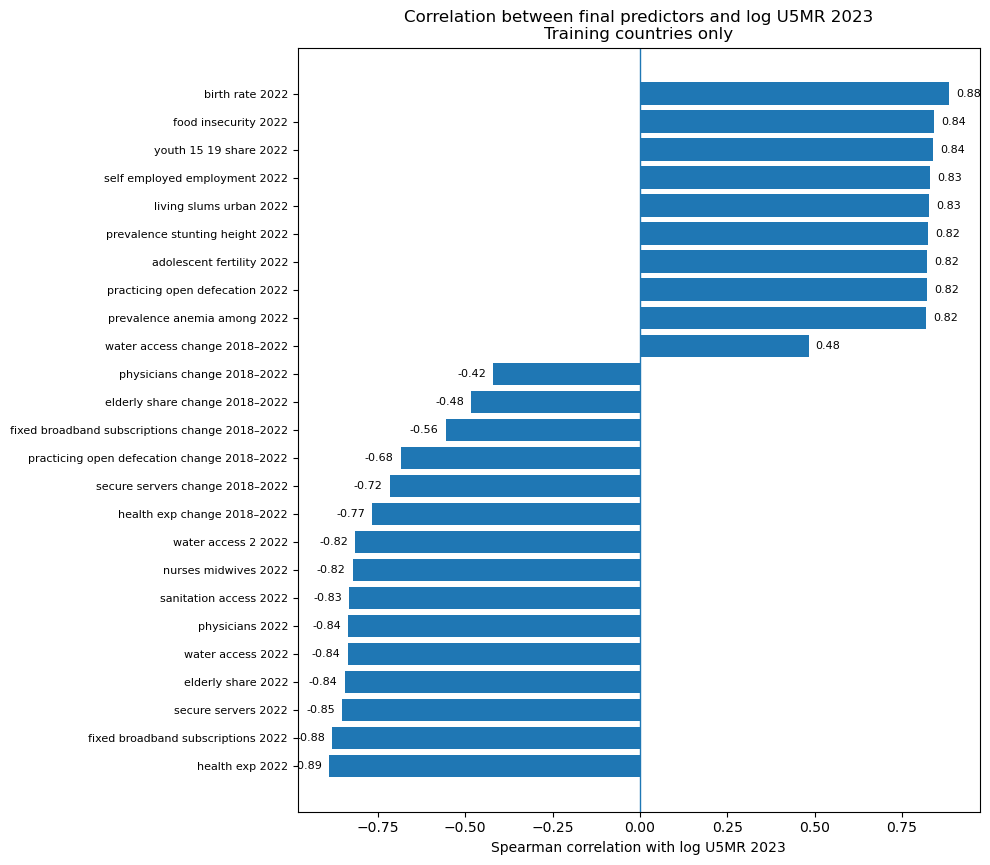

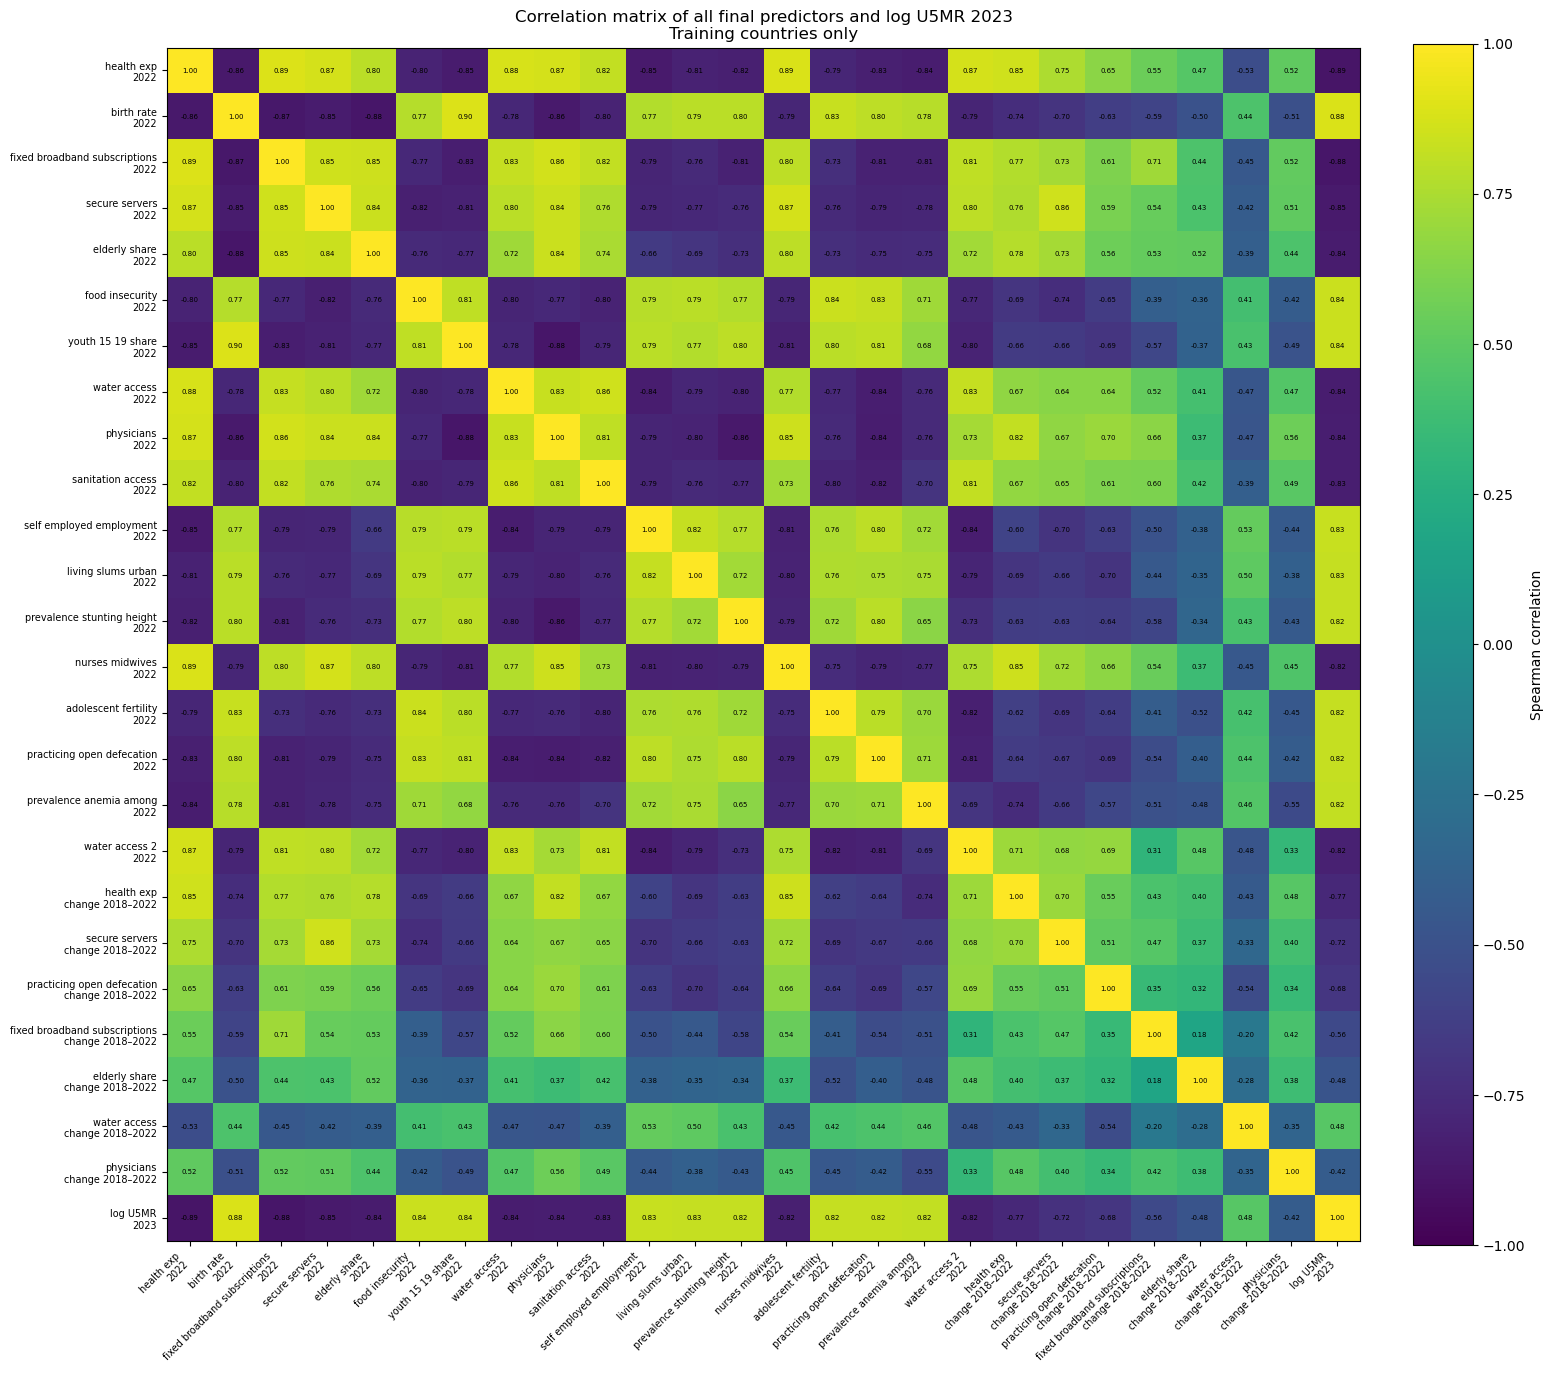

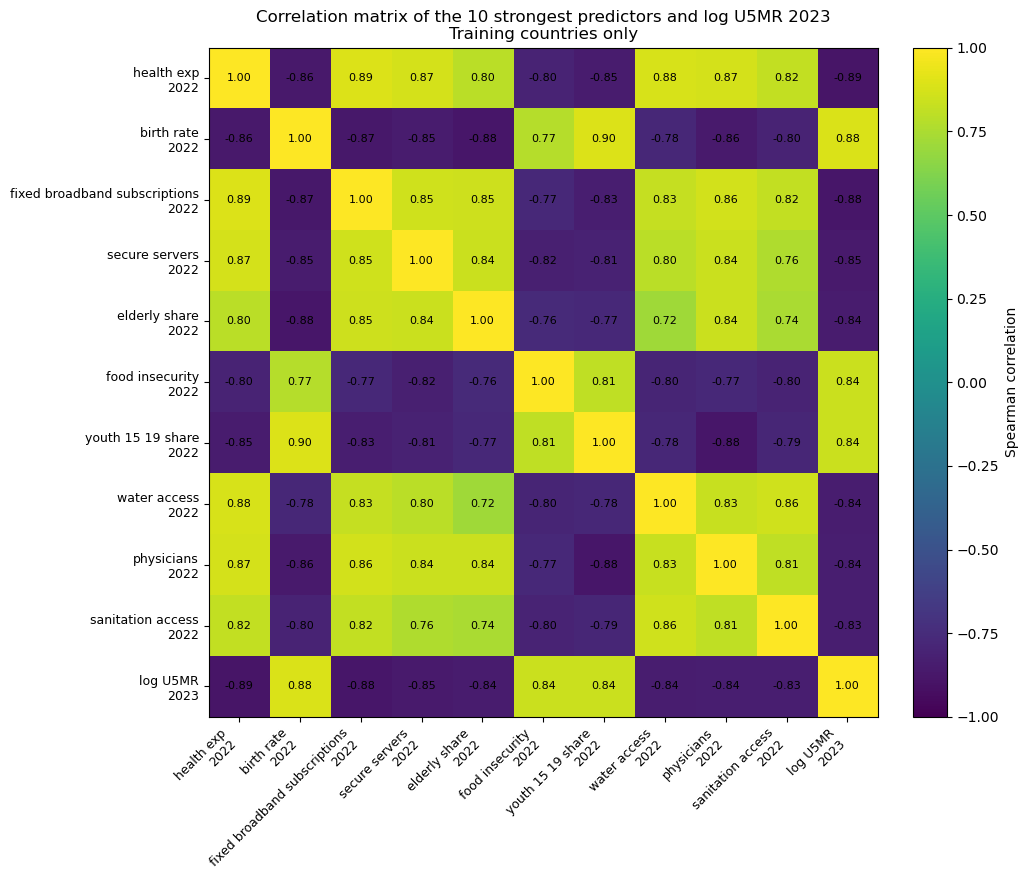

In [49]:
# Compact labels used only for plots.
def compact_feature_label(feature):
    if feature == "log_u5mr_2023":
        return "log U5MR\n2023"

    row = feature_dictionary.set_index("feature").loc[feature]
    base = row["predictor_name"].replace("_", " ")

    if feature.endswith(f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"):
        return f"{base}\nchange {CHANGE_START_YEAR}–{CHANGE_END_YEAR}"
    if feature.endswith(f"_{PREDICTOR_LEVEL_YEAR}"):
        return f"{base}\n{PREDICTOR_LEVEL_YEAR}"
    return feature.replace("_", " ")

train_model_data_for_corr = model_data[model_data["country_code"].isin(train_codes)].copy()

# Correlation of every final predictor with the target.
corr_to_target = (
    train_model_data_for_corr[kept_feature_columns + ["log_u5mr_2023"]]
    .corr(method="spearman")["log_u5mr_2023"]
    .drop("log_u5mr_2023")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_table = pd.DataFrame({
    "feature": corr_to_target.index,
    "plot_label": [compact_feature_label(feature).replace("\n", " ") for feature in corr_to_target.index],
    "spearman_corr_with_log_u5mr": corr_to_target.values,
    "abs_corr": corr_to_target.abs().values
}).merge(
    feature_dictionary[["feature", "predictor_name", "domain", "indicator_code", "indicator_name"]],
    on="feature",
    how="left"
)

corr_table.to_csv(TABLE_DIR / "final_predictor_correlations_training_only.csv", index=False)

print("Final engineered predictors included in the model:", len(kept_feature_columns))
display(corr_table[[
    "predictor_name",
    "domain",
    "feature",
    "spearman_corr_with_log_u5mr"
]])

# Bar plot: every final predictor ranked by correlation with the target.
plot_corr = corr_table.sort_values("spearman_corr_with_log_u5mr").copy()

fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(plot_corr))))
y_pos = np.arange(len(plot_corr))
ax.barh(y_pos, plot_corr["spearman_corr_with_log_u5mr"])
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_corr["plot_label"], fontsize=8)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Spearman correlation with log U5MR 2023")
ax.set_title("Correlation between final predictors and log U5MR 2023\nTraining countries only")

for i, value in enumerate(plot_corr["spearman_corr_with_log_u5mr"]):
    offset = 0.02 if value >= 0 else -0.02
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, i, f"{value:.2f}", va="center", ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "final_predictor_target_correlations_training_only.png", dpi=300)
plt.show()

# Full correlation matrix for all final predictors.
full_matrix_cols = kept_feature_columns + ["log_u5mr_2023"]
full_corr_matrix = train_model_data_for_corr[full_matrix_cols].corr(method="spearman")
full_matrix_labels = [compact_feature_label(col) for col in full_matrix_cols]

matrix_size = len(full_matrix_cols)
fig_width = max(13, 0.60 * matrix_size)
fig_height = max(11, 0.55 * matrix_size)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(full_corr_matrix.values, vmin=-1, vmax=1, aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")

ax.set_xticks(np.arange(matrix_size))
ax.set_yticks(np.arange(matrix_size))
ax.set_xticklabels(full_matrix_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(full_matrix_labels, fontsize=7)
ax.set_title("Correlation matrix of all final predictors and log U5MR 2023\nTraining countries only")

for i in range(matrix_size):
    for j in range(matrix_size):
        value = full_corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=5)

plt.tight_layout()
plt.savefig(VIS_DIR / "all_final_predictors_correlation_matrix_training_only.png", dpi=300)
plt.show()

# Smaller matrix for strongest predictors only.
TOP_N_MATRIX = min(10, len(kept_feature_columns))

top_matrix_features = corr_table.head(TOP_N_MATRIX)["feature"].tolist()
top_matrix_cols = top_matrix_features + ["log_u5mr_2023"]
top_corr_matrix = train_model_data_for_corr[top_matrix_cols].corr(method="spearman")
top_matrix_labels = [compact_feature_label(col) for col in top_matrix_cols]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(top_corr_matrix.values, vmin=-1, vmax=1, aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")

ax.set_xticks(np.arange(len(top_matrix_cols)))
ax.set_yticks(np.arange(len(top_matrix_cols)))
ax.set_xticklabels(top_matrix_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(top_matrix_labels, fontsize=9)
ax.set_title(
    f"Correlation matrix of the {TOP_N_MATRIX} strongest predictors and log U5MR 2023\n"
    "Training countries only"
)

for i in range(len(top_matrix_cols)):
    for j in range(len(top_matrix_cols)):
        value = top_corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "top_final_predictors_correlation_matrix_training_only.png", dpi=300)
plt.show()


## 7.9 Save final cross-sectional modeling data

In [50]:
model_data.to_csv(DATA_DIR / "final_cross_sectional_model_data_leakage_safe_year_named.csv", index=False)
train_model_data = model_data[model_data["country_code"].isin(train_codes)].copy()
test_model_data = model_data[model_data["country_code"].isin(test_codes)].copy()
train_model_data.to_csv(DATA_DIR / "train_model_data.csv", index=False)
test_model_data.to_csv(DATA_DIR / "test_model_data.csv", index=False)

print("Final model_data shape:", model_data.shape)
print("Train model_data shape:", train_model_data.shape)
print("Test model_data shape:", test_model_data.shape)

Final model_data shape: (196, 29)
Train model_data shape: (147, 29)
Test model_data shape: (49, 29)


# Stage 8 — Model Selection

The candidate models are regression models only. A dummy regressor is included as a baseline but is never selected as the final substantive model.

## 8.1 Prepare model inputs

In [51]:
X_train = train_model_data[kept_feature_columns]
y_train = train_model_data["log_u5mr_2023"]
X_test = test_model_data[kept_feature_columns]
y_test = test_model_data["log_u5mr_2023"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (147, 25)
X_test: (49, 25)


## 8.2 Define model pipelines

In [52]:
def scaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])


def tree_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

model_catalogue = {
    "Dummy mean": tree_pipeline(DummyRegressor(strategy="mean")),
    "Ridge": scaled_pipeline(Ridge(random_state=RANDOM_STATE)),
    "ElasticNet": scaled_pipeline(ElasticNet(max_iter=10000, random_state=RANDOM_STATE)),
    "KNN": scaled_pipeline(KNeighborsRegressor()),
    "Random Forest": tree_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "Extra Trees": tree_pipeline(ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting": tree_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE))
}

list(model_catalogue.keys())

['Dummy mean',
 'Ridge',
 'ElasticNet',
 'KNN',
 'Random Forest',
 'Extra Trees',
 'Gradient Boosting']

# Stage 9 — Model Training and Cross-Validation

Cross-validation is performed on training countries only. Because the sample is small, CV results should be interpreted as approximate rather than definitive.

The country-level design produces fewer than 200 observations overall. With a 75/25 split, each five-fold CV validation fold contains only a small number of countries. This limitation is especially relevant for flexible ensemble models such as Random Forest and Extra Trees, which can fit complex patterns when the number of predictors is high relative to the sample size. The notebook therefore uses modest tuning, restricts the final predictor count, reports test-set bootstrap intervals, and avoids causal interpretation.

## 9.1 Cross-validation setup

In [53]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 9.2 Train and compare models using training CV

In [54]:
def evaluate_predictions(y_true_log, y_pred_log):
    return {
        "rmse_log": root_mean_squared_error(y_true_log, y_pred_log),
        "mae_log": mean_absolute_error(y_true_log, y_pred_log),
        "r2_log": r2_score(y_true_log, y_pred_log),
        "mae_original_scale": mean_absolute_error(np.exp(y_true_log), np.exp(y_pred_log))
    }

cv_rows = []
fitted_initial_models = {}

for model_name, pipeline in model_catalogue.items():
    cv_scores = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    pipeline.fit(X_train, y_train)
    fitted_initial_models[model_name] = pipeline

    cv_rows.append({
        "model": model_name,
        "cv_rmse_log_mean": cv_scores.mean(),
        "cv_rmse_log_std": cv_scores.std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_rmse_log_mean")
cv_results.to_csv(TABLE_DIR / "cv_model_comparison_train_only.csv", index=False)
display(cv_results)

best_cv_model_name = cv_results[cv_results["model"] != "Dummy mean"].iloc[0]["model"]
print("Best non-dummy model by training CV:", best_cv_model_name)

,model,cv_rmse_log_mean,cv_rmse_log_std
5,Extra Trees,0.371552,0.051505
4,Random Forest,0.376973,0.037556
6,Gradient Boosting,0.385421,0.048137
3,KNN,0.431822,0.036563
1,Ridge,0.452898,0.056710
2,ElasticNet,0.748254,0.045241
0,Dummy mean,1.083540,0.075684


Best non-dummy model by training CV: Extra Trees


# Stage 10 — Model Evaluation and Hyperparameter Tuning

The test set is used for final evaluation, not for feature selection or hyperparameter tuning. Model choice is based on training cross-validation.

## 10.1 Initial test evaluation for reporting

In [55]:
initial_test_rows = []

for model_name, pipeline in fitted_initial_models.items():
    test_pred = pipeline.predict(X_test)
    metrics = evaluate_predictions(y_test, test_pred)
    initial_test_rows.append({"model": model_name, **metrics})

initial_test_results = pd.DataFrame(initial_test_rows).sort_values("rmse_log")
initial_test_results.to_csv(TABLE_DIR / "initial_test_model_comparison.csv", index=False)
display(initial_test_results)

,model,rmse_log,mae_log,r2_log,mae_original_scale
5,Extra Trees,0.346424,0.270311,0.899008,6.887858
4,Random Forest,0.371681,0.297828,0.883744,7.248726
6,Gradient Boosting,0.374367,0.291175,0.882058,7.318576
3,KNN,0.442442,0.337170,0.835265,7.401257
1,Ridge,0.600008,0.390292,0.697039,12.824884
2,ElasticNet,0.704211,0.577577,0.582671,13.658437
0,Dummy mean,1.091368,0.885276,-0.002340,18.507869


## 10.2 Model comparison plot

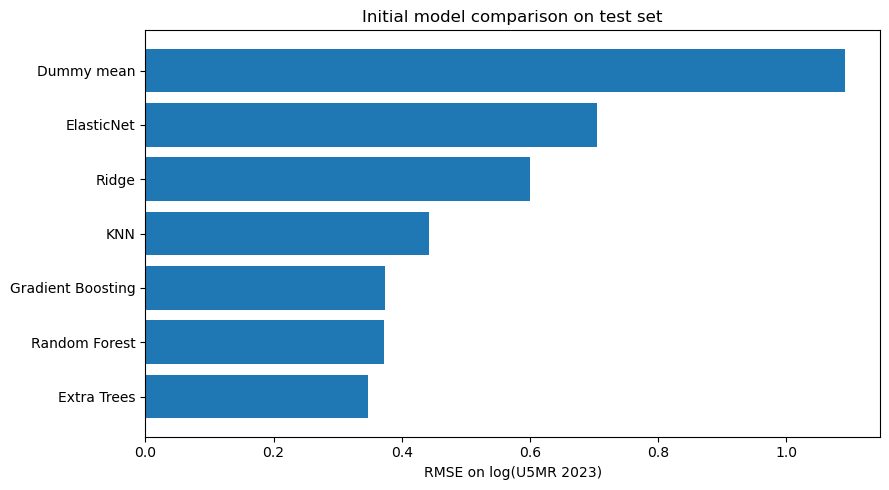

In [56]:
plot_df = initial_test_results.sort_values("rmse_log", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["rmse_log"])
plt.title("Initial model comparison on test set")
plt.xlabel("RMSE on log(U5MR 2023)")
plt.tight_layout()
plt.savefig(VIS_DIR / "initial_model_comparison_rmse_log.png", dpi=300)
plt.show()

## 10.3 Modest hyperparameter tuning on training data only

In [57]:
top_models_for_tuning = cv_results[cv_results["model"] != "Dummy mean"].head(3)["model"].tolist()
print("Models selected for tuning based on training CV:", top_models_for_tuning)

param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "Random Forest": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Extra Trees": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [1, 3, 5]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    }
}

tuning_rows = []
tuned_models = {}

for model_name in top_models_for_tuning:
    if model_name not in param_grids:
        continue

    total_combinations = int(np.prod([len(v) for v in param_grids[model_name].values()]))
    search = RandomizedSearchCV(
        estimator=model_catalogue[model_name],
        param_distributions=param_grids[model_name],
        n_iter=min(10, total_combinations),
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_models[model_name + " tuned"] = search.best_estimator_
    tuning_rows.append({
        "model": model_name + " tuned",
        "cv_rmse_log_mean": -search.best_score_,
        "best_params": search.best_params_
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("cv_rmse_log_mean")
tuning_results.to_csv(TABLE_DIR / "tuning_results_train_only.csv", index=False)
display(tuning_results)

Models selected for tuning based on training CV: ['Extra Trees', 'Random Forest', 'Gradient Boosting']


,model,cv_rmse_log_mean,best_params
0,Extra Trees tuned,0.366080,"{'model__n_estimators': 300, 'model__min_sampl..."
1,Random Forest tuned,0.369594,"{'model__n_estimators': 600, 'model__min_sampl..."
2,Gradient Boosting tuned,0.378526,"{'model__n_estimators': 100, 'model__min_sampl..."


## 10.4 Select the final model using training CV only

In [58]:
initial_cv_for_selection = cv_results[cv_results["model"] != "Dummy mean"][["model", "cv_rmse_log_mean"]].copy()
combined_cv_selection = pd.concat([
    initial_cv_for_selection,
    tuning_results[["model", "cv_rmse_log_mean"]] if len(tuning_results) else pd.DataFrame(columns=["model", "cv_rmse_log_mean"])
], ignore_index=True).sort_values("cv_rmse_log_mean")

final_model_name = combined_cv_selection.iloc[0]["model"]

if final_model_name in tuned_models:
    final_model = tuned_models[final_model_name]
else:
    final_model = fitted_initial_models[final_model_name]

final_model.fit(X_train, y_train)
print("Final selected model based on training CV:", final_model_name)
display(combined_cv_selection)

Final selected model based on training CV: Extra Trees tuned


,model,cv_rmse_log_mean
6,Extra Trees tuned,0.366080
7,Random Forest tuned,0.369594
0,Extra Trees,0.371552
1,Random Forest,0.376973
8,Gradient Boosting tuned,0.378526
2,Gradient Boosting,0.385421
3,KNN,0.431822
4,Ridge,0.452898
5,ElasticNet,0.748254


## 10.5 Final test evaluation

In [59]:
final_test_pred_log = final_model.predict(X_test)
dummy_test_pred_log = fitted_initial_models["Dummy mean"].predict(X_test)

final_metrics = evaluate_predictions(y_test, final_test_pred_log)
dummy_metrics = evaluate_predictions(y_test, dummy_test_pred_log)

improvement_over_dummy = 100 * (dummy_metrics["rmse_log"] - final_metrics["rmse_log"]) / dummy_metrics["rmse_log"]

final_evaluation = pd.DataFrame([
    {"model": final_model_name, **final_metrics, "improvement_over_dummy_pct": improvement_over_dummy},
    {"model": "Dummy mean", **dummy_metrics, "improvement_over_dummy_pct": 0.0}
])

final_evaluation.to_csv(TABLE_DIR / "final_test_evaluation.csv", index=False)
display(final_evaluation)

,model,rmse_log,mae_log,r2_log,mae_original_scale,improvement_over_dummy_pct
0,Extra Trees tuned,0.346159,0.269338,0.899162,6.768375,68.282062
1,Dummy mean,1.091368,0.885276,-0.002340,18.507869,0.000000


## 10.6 Bootstrap uncertainty for final test metrics

In [60]:
bootstrap_rows = []
rng = np.random.default_rng(RANDOM_STATE)
y_test_array = np.asarray(y_test)
pred_array = np.asarray(final_test_pred_log)

for _ in range(500):
    sample_idx = rng.integers(0, len(y_test_array), size=len(y_test_array))
    y_boot = y_test_array[sample_idx]
    pred_boot = pred_array[sample_idx]
    bootstrap_rows.append(evaluate_predictions(y_boot, pred_boot))

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci = bootstrap_df.quantile([0.025, 0.5, 0.975]).T.rename(columns={0.025: "ci_2_5", 0.5: "median", 0.975: "ci_97_5"})
bootstrap_ci.to_csv(TABLE_DIR / "final_test_metric_bootstrap_ci.csv")
display(bootstrap_ci)

,ci_2_5,median,ci_97_5
rmse_log,0.270589,0.341554,0.409121
mae_log,0.212040,0.269366,0.325239
r2_log,0.838261,0.897094,0.937808
mae_original_scale,3.876839,6.640603,9.883233


## 10.7 Save final predictions

In [61]:
final_predictions = test_model_data[["country_code", "country_name", "u5mr_2023", "log_u5mr_2023"]].copy()
final_predictions["pred_log_u5mr_2023"] = final_test_pred_log
final_predictions["pred_u5mr_2023"] = np.exp(final_test_pred_log)
final_predictions["residual_log"] = final_predictions["log_u5mr_2023"] - final_predictions["pred_log_u5mr_2023"]
final_predictions["absolute_error_original"] = (final_predictions["u5mr_2023"] - final_predictions["pred_u5mr_2023"]).abs()

final_predictions.to_csv(DATA_DIR / "final_test_predictions.csv", index=False)
display(final_predictions.sort_values("absolute_error_original", ascending=False).head(10))

,country_code,country_name,u5mr_2023,log_u5mr_2023,pred_log_u5mr_2023,pred_u5mr_2023,residual_log,absolute_error_original
124,SOM,"Somalia, Federal Republic of",104.0,4.644391,3.796010,44.523163,0.848381,59.476837
170,SLE,Sierra Leone,94.3,4.546481,3.972095,53.095661,0.574386,41.204339
107,MLI,Mali,91.3,4.514151,4.049329,57.358948,0.464822,33.941052
159,TCD,Chad,101.1,4.616110,4.405729,81.918819,0.210381,19.181181
54,LSO,Lesotho,58.9,4.075841,3.736525,41.951942,0.339316,16.948058
142,CIV,Côte d’Ivoire,67.1,4.206184,3.976186,53.313309,0.229998,13.786691
129,PLW,Palau,22.3,3.104587,2.220251,9.209646,0.884335,13.090354
34,LBY,Libya,30.8,3.427515,2.878581,17.789012,0.548934,13.010988
91,UGA,Uganda,38.8,3.658420,3.919336,50.367011,-0.260916,11.567011
144,CPV,Cabo Verde,11.6,2.451005,3.126071,22.784290,-0.675066,11.184290


## 10.8 Subgroup error analysis

Overall RMSE and MAE can hide uneven performance across groups of countries. This diagnostic section evaluates errors by U5MR level and, when available, by an income proxy from WDI. The subgroup analysis is not used for model selection; it is used only to understand where the final model performs better or worse.

The groups are built only after final model evaluation, so they do not affect training, feature selection, or tuning.

No sufficiently complete WDI income proxy was available for test-country subgroup analysis.


,grouping_variable,group,n_countries,mean_actual_u5mr,median_actual_u5mr,mae_original_scale,rmse_log,mean_residual_log_actual_minus_predicted
0,u5mr_test_quartile,highest U5MR countries,12,67.483333,63.25,18.075836,0.367241,0.187995
1,u5mr_test_quartile,lower-middle U5MR countries,12,12.083333,12.70,3.007607,0.276719,-0.072658
2,u5mr_test_quartile,lowest U5MR countries,13,3.807692,3.70,1.346638,0.371130,-0.096710
3,u5mr_test_quartile,upper-middle U5MR countries,12,22.966667,22.70,5.095230,0.358658,0.139312


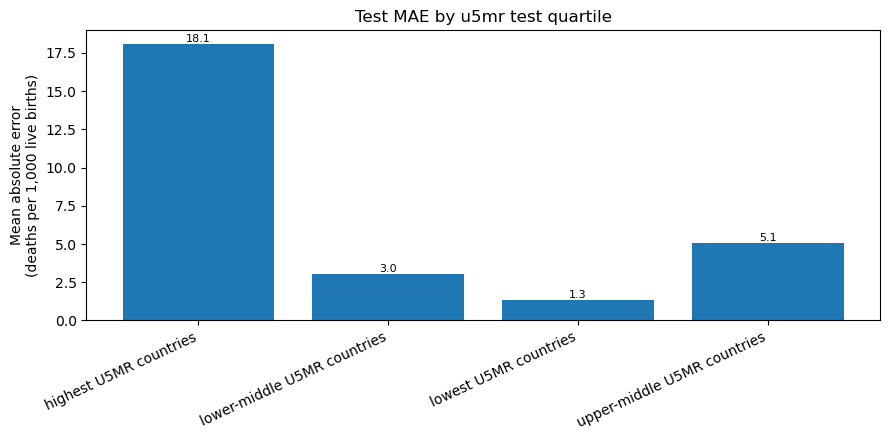

In [62]:
# ------------------------------------------------------------
# Subgroup error analysis on the held-out test countries
# ------------------------------------------------------------

def make_quantile_groups(series, labels):
    """Create quantile groups with robust handling of tied values."""
    series = pd.Series(series)
    try:
        codes = pd.qcut(series, q=len(labels), labels=False, duplicates="drop")
        if codes.notna().sum() == 0:
            return pd.Series(pd.NA, index=series.index, dtype="object")
        n_groups = int(codes.max()) + 1
        label_map = {i: labels[i] for i in range(n_groups)}
        return codes.map(label_map).astype("object")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="object")

# U5MR-level groups are always available and show whether errors differ between
# low-, middle-, and high-mortality countries.
u5mr_group_labels = [
    "lowest U5MR countries",
    "lower-middle U5MR countries",
    "upper-middle U5MR countries",
    "highest U5MR countries"
]
final_predictions["u5mr_test_quartile"] = make_quantile_groups(
    final_predictions["u5mr_2023"],
    u5mr_group_labels
)

# Income proxy groups are useful for policy interpretation. The raw WDI file does
# not provide an official income-group column, so the notebook uses a 2022 income
# proxy if available. This is a diagnostic grouping only, not a model feature.
income_proxy_candidates = [
    ("NY.GNP.PCAP.CD", "GNI per capita, Atlas method, current US$"),
    ("NY.GDP.PCAP.CD", "GDP per capita, current US$"),
    ("NY.GDP.PCAP.KD", "GDP per capita, constant 2015 US$"),
]

best_income_proxy = None
best_income_proxy_label = None
best_income_proxy_coverage = -1

for indicator_code, indicator_label in income_proxy_candidates:
    candidate_rows = country_wdi[country_wdi["indicator_code"] == indicator_code].copy()
    if candidate_rows.empty:
        continue

    candidate_values = (
        fixed_year_values(
            candidate_rows,
            PREDICTOR_LEVEL_YEAR,
            value_name="income_proxy_2022"
        )[["country_code", "income_proxy_2022"]]
        .drop_duplicates(subset=["country_code"])
    )

    coverage = (
        final_predictions[["country_code"]]
        .merge(candidate_values, on="country_code", how="left")["income_proxy_2022"]
        .notna()
        .mean()
    )

    if coverage > best_income_proxy_coverage:
        best_income_proxy = candidate_values
        best_income_proxy_label = indicator_label
        best_income_proxy_coverage = coverage

if best_income_proxy is not None and best_income_proxy_coverage >= 0.50:
    final_predictions = final_predictions.merge(best_income_proxy, on="country_code", how="left")
    income_group_labels = [
        "lowest income-proxy countries",
        "lower-middle income-proxy countries",
        "upper-middle income-proxy countries",
        "highest income-proxy countries"
    ]
    final_predictions["income_proxy_quartile"] = make_quantile_groups(
        final_predictions["income_proxy_2022"],
        income_group_labels
    )
    print(f"Income proxy used for subgroup analysis: {best_income_proxy_label}")
    print(f"Income proxy coverage in test set: {best_income_proxy_coverage:.1%}")
else:
    final_predictions["income_proxy_2022"] = np.nan
    final_predictions["income_proxy_quartile"] = pd.NA
    print("No sufficiently complete WDI income proxy was available for test-country subgroup analysis.")


def subgroup_metric_table(prediction_df, group_column):
    rows = []
    valid_df = prediction_df.dropna(subset=[group_column]).copy()

    for group_value, group_df in valid_df.groupby(group_column, observed=True):
        if len(group_df) == 0:
            continue

        rmse_log_group = np.sqrt(
            np.mean((group_df["log_u5mr_2023"] - group_df["pred_log_u5mr_2023"]) ** 2)
        )

        rows.append({
            "grouping_variable": group_column,
            "group": str(group_value),
            "n_countries": len(group_df),
            "mean_actual_u5mr": group_df["u5mr_2023"].mean(),
            "median_actual_u5mr": group_df["u5mr_2023"].median(),
            "mae_original_scale": group_df["absolute_error_original"].mean(),
            "rmse_log": rmse_log_group,
            "mean_residual_log_actual_minus_predicted": group_df["residual_log"].mean()
        })

    return pd.DataFrame(rows)

subgroup_tables = [subgroup_metric_table(final_predictions, "u5mr_test_quartile")]

if final_predictions["income_proxy_quartile"].notna().sum() >= 8:
    subgroup_tables.append(subgroup_metric_table(final_predictions, "income_proxy_quartile"))

subgroup_error_table = pd.concat(subgroup_tables, ignore_index=True)
subgroup_error_table.to_csv(TABLE_DIR / "subgroup_error_analysis_test_set.csv", index=False)
final_predictions.to_csv(DATA_DIR / "final_test_predictions_with_subgroups.csv", index=False)

display(subgroup_error_table)

# Plot subgroup MAE on the original U5MR scale.
for group_var in subgroup_error_table["grouping_variable"].unique():
    plot_df = subgroup_error_table[subgroup_error_table["grouping_variable"] == group_var].copy()

    plt.figure(figsize=(9, 4.5))
    plt.bar(plot_df["group"], plot_df["mae_original_scale"])
    plt.title(f"Test MAE by {group_var.replace('_', ' ')}")
    plt.ylabel("Mean absolute error\n(deaths per 1,000 live births)")
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")

    for i, value in enumerate(plot_df["mae_original_scale"]):
        plt.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    safe_group_name = group_var.replace(" ", "_").lower()
    plt.savefig(VIS_DIR / f"test_mae_by_{safe_group_name}.png", dpi=300)
    plt.show()


### Subgroup-error interpretation

The subgroup table should be read as a diagnostic check, not as a separate model-selection procedure. Some groups contain few countries, so differences in subgroup MAE or RMSE can be unstable. Nevertheless, the table is useful because it shows whether the model errors are concentrated among low-mortality, high-mortality, lower-income, or higher-income countries.

## 10.8 Actual vs predicted plot

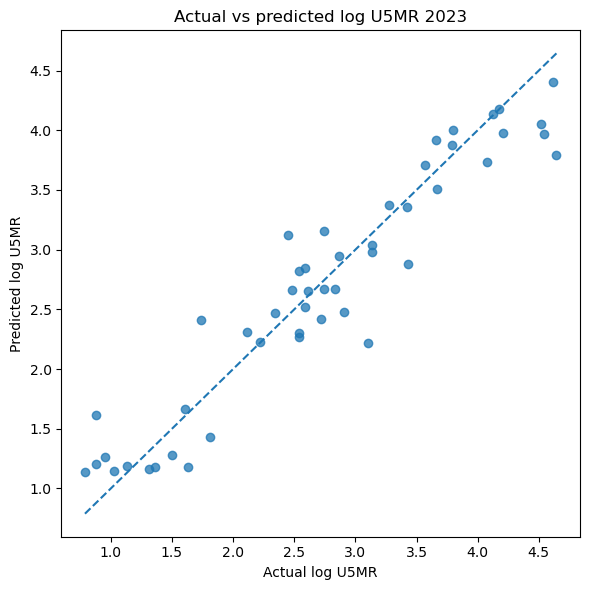

In [63]:
plt.figure(figsize=(6, 6))
plt.scatter(final_predictions["log_u5mr_2023"], final_predictions["pred_log_u5mr_2023"], alpha=0.75)
min_value = min(final_predictions["log_u5mr_2023"].min(), final_predictions["pred_log_u5mr_2023"].min())
max_value = max(final_predictions["log_u5mr_2023"].max(), final_predictions["pred_log_u5mr_2023"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs predicted log U5MR 2023")
plt.xlabel("Actual log U5MR")
plt.ylabel("Predicted log U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "actual_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.9 Residual plot

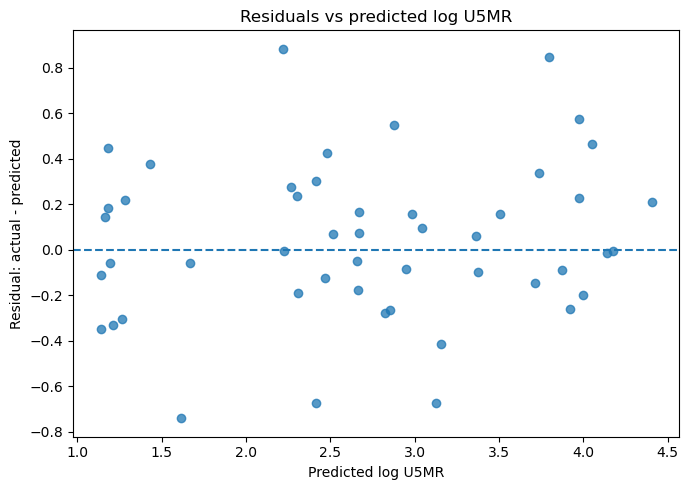

In [64]:
plt.figure(figsize=(7, 5))
plt.scatter(final_predictions["pred_log_u5mr_2023"], final_predictions["residual_log"], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs predicted log U5MR")
plt.xlabel("Predicted log U5MR")
plt.ylabel("Residual: actual - predicted")
plt.tight_layout()
plt.savefig(VIS_DIR / "residuals_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.10 Permutation feature importance

In [65]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = pd.DataFrame({
    "feature": kept_feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_table = importance_table.merge(
    feature_dictionary[["feature", "predictor_name", "feature_type", "domain", "indicator_name"]],
    on="feature",
    how="left"
)

importance_table.to_csv(TABLE_DIR / "permutation_feature_importance.csv", index=False)
display(importance_table.head(15))

,feature,importance_mean,importance_std,predictor_name,feature_type,domain,indicator_name
0,fixed_broadband_subscriptions_2022,0.040112,0.009993,fixed_broadband_subscriptions,value in 2022,infrastructure,Fixed broadband subscriptions (per 100 people)
1,adolescent_fertility_2022,0.034335,0.008852,adolescent_fertility,value in 2022,demographic,"Adolescent fertility rate (births per 1,000 wo..."
2,birth_rate_2022,0.033444,0.011238,birth_rate,value in 2022,demographic,"Birth rate, crude (per 1,000 people)"
3,youth_15_19_share_2022,0.025321,0.007594,youth_15_19_share,value in 2022,demographic,"Population ages 15-19, male (% of male populat..."
4,health_exp_2022,0.024370,0.009968,health_exp,value in 2022,health system,"Current health expenditure per capita, PPP (cu..."
5,health_exp_change_2018_2022,0.022568,0.009167,health_exp,change from 2018 to 2022,health system,"Current health expenditure per capita, PPP (cu..."
6,elderly_share_2022,0.021380,0.007943,elderly_share,value in 2022,demographic,"Population ages 80 and above, male (% of male ..."
7,self_employed_employment_2022,0.019718,0.006389,self_employed_employment,value in 2022,economic,"Self-employed, female (% of female employment)..."
8,prevalence_stunting_height_2022,0.019026,0.006230,prevalence_stunting_height,value in 2022,demographic,"Prevalence of stunting, height for age, male (..."
9,sanitation_access_2022,0.016106,0.006245,sanitation_access,value in 2022,infrastructure,People using at least basic sanitation service...


## 10.11 Feature importance plot

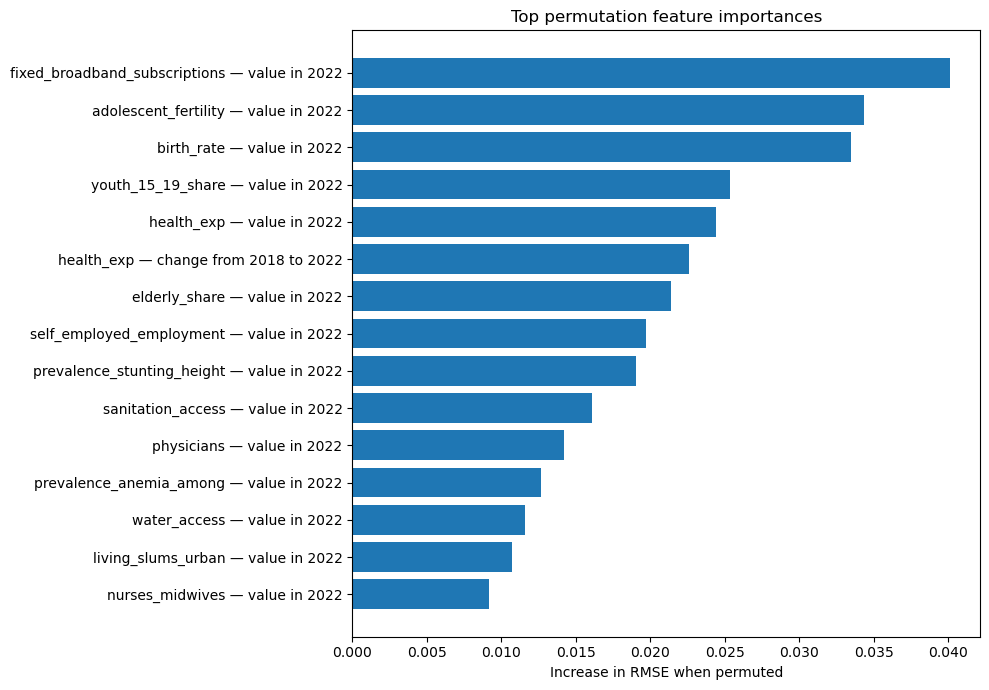

In [66]:
plot_importance = importance_table.head(15).copy().sort_values("importance_mean")
plot_labels = plot_importance["predictor_name"] + " — " + plot_importance["feature_type"]

plt.figure(figsize=(10, 7))
plt.barh(plot_labels, plot_importance["importance_mean"])
plt.title("Top permutation feature importances")
plt.xlabel("Increase in RMSE when permuted")
plt.tight_layout()
plt.savefig(VIS_DIR / "permutation_feature_importance.png", dpi=300)
plt.show()

## 10.12 Report-ready interpretation paragraph

In [67]:
top_importance_rows = importance_table.head(5).copy()

def format_predictor_for_text(row):
    predictor = str(row["predictor_name"]).replace("_", " ")
    feature_type = str(row["feature_type"])
    domain = str(row["domain"])
    return f"{predictor} ({feature_type}; {domain})"

top_predictor_text = "; ".join(
    top_importance_rows.apply(format_predictor_for_text, axis=1).tolist()
)

proxy_predictors = [
    str(name).replace("_", " ")
    for name in top_importance_rows["predictor_name"].dropna().unique()
    if any(term in str(name).lower() for term in ["broadband", "server", "internet", "electricity"])
]

if proxy_predictors:
    proxy_sentence = (
        " Infrastructure and digital-access predictors such as "
        + ", ".join(proxy_predictors)
        + " are interpreted as broad development proxies rather than direct causal mechanisms."
    )
else:
    proxy_sentence = ""

if "subgroup_error_table" in globals() and len(subgroup_error_table) > 0:
    largest_error_row = subgroup_error_table.sort_values("mae_original_scale", ascending=False).iloc[0]
    subgroup_sentence = (
        f" The subgroup diagnostic found the largest mean absolute error in the "
        f"'{largest_error_row['group']}' group under {largest_error_row['grouping_variable']}, "
        f"but subgroup results should be interpreted cautiously because each group contains few countries."
    )
else:
    subgroup_sentence = ""

sample_size_sentence = (
    f" Because the evaluation uses {len(y_test)} test countries and the training set is small, "
    "the reported metrics should be interpreted together with the bootstrap confidence intervals."
)

report_paragraph = (
    f"The selected {final_model_name} model achieved test RMSE_log = {final_metrics['rmse_log']:.3f} "
    f"compared with the dummy baseline RMSE_log = {dummy_metrics['rmse_log']:.3f}, representing a "
    f"{improvement_over_dummy:.1f}% improvement. The test R² of {final_metrics['r2_log']:.3f} means "
    f"the model explains approximately {final_metrics['r2_log'] * 100:.1f}% of the cross-country variation "
    f"in log under-five mortality. The most important predictors were {top_predictor_text}. These variables "
    f"suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, "
    f"and infrastructure are useful for predicting cross-country differences in child mortality."
    f"{proxy_sentence} {sample_size_sentence}{subgroup_sentence} "
    "The results should be interpreted as predictive associations, not causal effects."
)

print(report_paragraph)
with open(REPORT_DIR / "final_report_ready_paragraph.txt", "w", encoding="utf-8") as f:
    f.write(report_paragraph)


The selected Extra Trees tuned model achieved test RMSE_log = 0.346 compared with the dummy baseline RMSE_log = 1.091, representing a 68.3% improvement. The test R² of 0.899 means the model explains approximately 89.9% of the cross-country variation in log under-five mortality. The most important predictors were fixed broadband subscriptions (value in 2022; infrastructure); adolescent fertility (value in 2022; demographic); birth rate (value in 2022; demographic); youth 15 19 share (value in 2022; demographic); health exp (value in 2022; health system). These variables suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, and infrastructure are useful for predicting cross-country differences in child mortality. Infrastructure and digital-access predictors such as fixed broadband subscriptions are interpreted as broad development proxies rather than direct causal mechanisms.  Because the evaluation uses 49 test countries and the trai

# Stage 11 — Deployment Discussion

This project is academic and is not deployed as a production system. In a real policy environment, the model could later support a monitoring dashboard that highlights countries whose lagged development indicators are associated with higher expected child mortality.

Such a dashboard should not replace expert judgment. It should be used as a screening and prioritization tool, and its outputs should be interpreted as predictive signals rather than causal claims.

# Stage 12 — Monitoring and Maintenance

Future maintenance should include:

- updating the raw WDI file when new data are released;
- checking whether U5MR 2024 or 2025 becomes available with sufficient coverage;
- monitoring changes in indicator missingness and country coverage;
- repeating the leakage-safe training-only feature selection process;
- checking whether model errors are concentrated in particular groups of countries;
- comparing subgroup performance across U5MR-level and income-proxy groups;
- retraining and comparing predictions with future U5MR values when they become available.

The model should be retrained only when enough new target values are available to evaluate it properly. Since the country-level sample is inherently small, future model comparisons should continue to report uncertainty intervals and should avoid over-interpreting small differences between complex models.

# Final  Conclusion

The final modeling dataset is cross-sectional, with one row per country. Historical information is preserved through recent 5-year change features rather than by keeping the country-year panel structure.

The workflow improves academic validity by performing supervised indicator selection on training countries only. This avoids using test-country target values during feature screening. Predictor variables are built from 2022 values and 2018–2022 changes, so no predictor source year overlaps with the 2023 target year.

The COVID-period analysis is included as descriptive EDA. It helps contextualize U5MR trends before, during, and after the pandemic, but it is not treated as causal evidence and does not change the main research question. Recent WDI U5MR values may also be smoothed or estimated, which helps explain why short-term pandemic shocks may not appear as sharp annual changes in the country-level series.

The final model performance should be interpreted with the sample size in mind. The dataset contains fewer than 200 countries, and the training folds used in cross-validation contain a limited number of countries. This is why the notebook restricts the predictor count, uses modest hyperparameter tuning, reports bootstrap confidence intervals, and includes subgroup error checks.

A final limitation is that this is a country-level model. The results should not be interpreted as individual-level relationships, and they do not prove that changing one predictor would causally change child mortality. The findings are best understood as predictive associations that summarize cross-country patterns in WDI indicators and U5MR 2023.